<a href="https://colab.research.google.com/github/romidj/PFE-CpG-islands/blob/main/Dataset_Validation_sequence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Verification & Biological Sanity Checks


In [ ]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

## Embeddings

our notebook CpG_sequence+chromHMM Cell 167 confirmed shape (29,790 × 512) float32, 61 MB. The reload verification in Cell 168 passed allclose(atol=1e-6). This check re-confirms that the file on disk still matches what was written.

In [ ]:
import numpy as np, pandas as pd

emb   = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy')
index = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')

assert emb.shape  == (29790, 512), f"Shape wrong: {emb.shape}"
assert emb.dtype  == np.float32,   f"Dtype wrong: {emb.dtype}"
assert len(index) == emb.shape[0], f"Index mismatch: {len(index)} vs {emb.shape[0]}"

size_mb = emb.nbytes / 1e6
print(f"Shape  : {emb.shape}   ✅")
print(f"Dtype  : {emb.dtype}   ✅")
print(f"Memory : {size_mb:.1f} MB")
print(f"Index  : {len(index):,} rows aligned  ✅")

Shape  : (29790, 512)   ✅
Dtype  : float32   ✅
Memory : 61.0 MB
Index  : 29,790 rows aligned  ✅


Checking for NaN and inf values, supposed to be 0

In [ ]:
nan_count = int(np.isnan(emb).sum())
inf_count = int(np.isinf(emb).sum())

print(f"NaN values : {nan_count}   {'✅' if nan_count == 0 else '❌ CRITICAL'}")
print(f"Inf values : {inf_count}   {'✅' if inf_count == 0 else '❌ CRITICAL'}")

# Per-row check to identify which tiles are problematic if any
nan_rows = np.isnan(emb).any(axis=1).sum()
inf_rows = np.isinf(emb).any(axis=1).sum()
print(f"Rows with NaN : {nan_rows}")
print(f"Rows with Inf : {inf_rows}")

assert nan_count == 0 and inf_count == 0, "STOP — fix NaN/Inf before fusion"

NaN values : 0   ✅
Inf values : 0   ✅
Rows with NaN : 0
Rows with Inf : 0


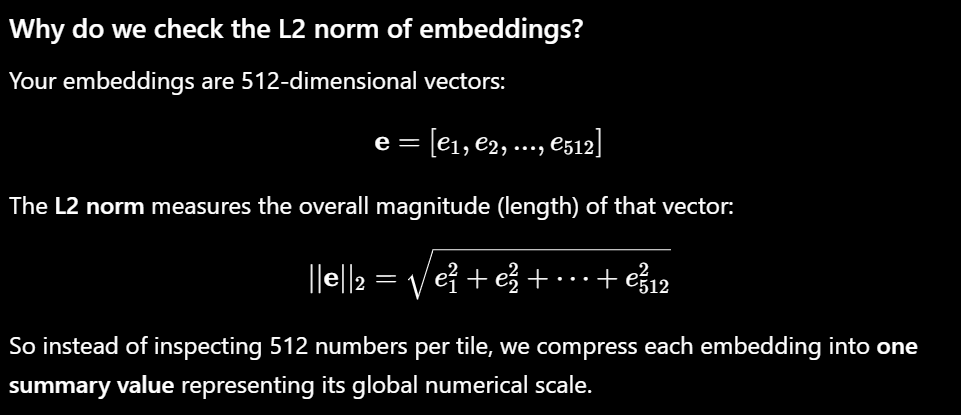

L2-norm stats:
  mean : 9.4993  (notebook: 9.499)
  std  : 0.4477   (notebook: 0.448)
  min  : 7.8752   (notebook: 7.875)
  max  : 14.0734   (notebook: 14.073)

Near-zero norms (< 1.0) : 0  ✅
High-norm outliers (>20) : 0  ✅


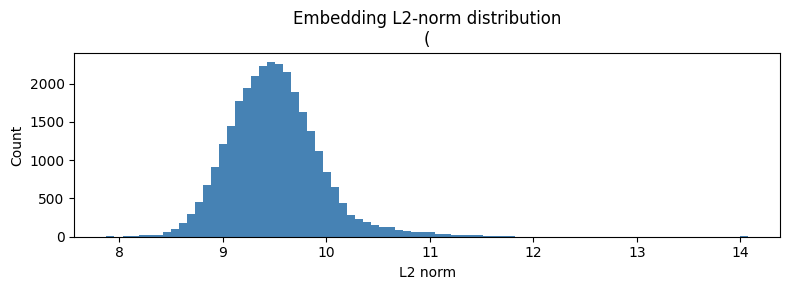

In [ ]:
norms = np.linalg.norm(emb, axis=1)  # (29790,)

print(f"L2-norm stats:")
print(f"  mean : {norms.mean():.4f}  (notebook: 9.499)")
print(f"  std  : {norms.std():.4f}   (notebook: 0.448)")
print(f"  min  : {norms.min():.4f}   (notebook: 7.875)")
print(f"  max  : {norms.max():.4f}   (notebook: 14.073)")

# Flag degenerate rows
near_zero = (norms < 1.0).sum()
outliers  = (norms > 20.0).sum()
print(f"\nNear-zero norms (< 1.0) : {near_zero}  {'✅' if near_zero == 0 else '❌'}")
print(f"High-norm outliers (>20) : {outliers}  {'✅' if outliers == 0 else '❌'}")

# Check for bimodal distribution (sign of mixed processing)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,3))
plt.hist(norms, bins=80, color='steelblue', edgecolor='none')
plt.xlabel('L2 norm'); plt.ylabel('Count')
plt.title('Embedding L2-norm distribution\n(')
plt.tight_layout(); plt.show()

The NT-v2 embedding vectors exhibited a stable and unimodal L2-norm distribution centered around 9.5, matching the expected statistics from the original extraction pipeline. No near-zero embeddings or extreme high-norm outliers were detected, indicating that all CGI windows were processed consistently and without numerical corruption. The absence of bimodality suggests that the embeddings originate from a single coherent representation regime rather than mixed preprocessing or tokenization artifacts. Overall, these results validate the numerical integrity and consistency of the 512-dimensional sequence embeddings prior to downstream epigenetic prediction tasks.

### Alignment integrity


---
verify tile_id order matches between embeddings and index


In [ ]:
import numpy as np, pandas as pd

emb   = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy', mmap_mode='r')
index = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')

# Build the mapping used at training time
tile_id_to_idx = {tid: i for i, tid in enumerate(index['tile_id'].values)}

# Spot-check 5 random tiles: retrieve embedding by tile_id and by position
rng = np.random.default_rng(42)
test_positions = rng.integers(0, len(index), size=5)

all_ok = True
for pos in test_positions:
    tile_id   = index['tile_id'].iloc[pos]
    mapped_pos = tile_id_to_idx[tile_id]
    # If alignment is correct, pos == mapped_pos
    if pos != mapped_pos:
        print(f"❌ MISALIGNMENT at position {pos}: tile_id={tile_id} maps to {mapped_pos}")
        all_ok = False
    else:
        # Also verify the embedding at that position is non-zero
        emb_row = emb[pos]
        assert not np.isnan(emb_row).any()
        print(f"  pos={pos} tile_id={tile_id} → embedding norm={np.linalg.norm(emb_row):.3f}  ✅")

if all_ok:
    print("\n✅ tile_id ↔ embedding row alignment confirmed")

  pos=2658 tile_id=chr10:28668479-28669187 → embedding norm=9.184  ✅
  pos=23056 tile_id=chr7:104983890-104984401 → embedding norm=8.939  ✅
  pos=19499 tile_id=chr4:168318398-168318673 → embedding norm=9.193  ✅
  pos=13074 tile_id=chr19:37468950-37469713 → embedding norm=9.361  ✅
  pos=12899 tile_id=chr19:30443915-30445719 → embedding norm=9.730  ✅

✅ tile_id ↔ embedding row alignment confirmed


In [ ]:
import pandas as pd, numpy as np

index = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')
epi   = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet')

emb_ids = set(index['tile_id'].values)
epi_ids = set(epi['tile_id'].unique())

only_in_emb = emb_ids - epi_ids
only_in_epi = epi_ids - emb_ids

print(f"Tiles in embedding index : {len(emb_ids):,}")
print(f"Unique tiles in epi_prof : {len(epi_ids):,}")
print(f"Only in embeddings       : {len(only_in_emb)}  {'✅' if not only_in_emb else '❌'}")
print(f"Only in epi_profiles     : {len(only_in_epi)}  {'✅' if not only_in_epi else '❌'}")

# Check the 412 all-zero tiles — where are they?
STATE_COLS = [c for c in epi.columns if c.startswith('state_')]
e003 = epi[epi['cell_type'] == 'E003']
zero_tiles = e003[e003[STATE_COLS].sum(axis=1) == 0]['tile_id'].values
print(f"\nAll-zero coverage tiles (E003): {len(zero_tiles)}")
zero_info = index[index['tile_id'].isin(zero_tiles)][['tile_id','chrom','win_start','win_end']]
print("Chromosome distribution of zero-coverage tiles:")
print(zero_info['chrom'].value_counts().head(20))

Tiles in embedding index : 29,790
Unique tiles in epi_prof : 29,790
Only in embeddings       : 0  ✅
Only in epi_profiles     : 0  ✅

All-zero coverage tiles (E003): 412
Chromosome distribution of zero-coverage tiles:
chrom
chr21    94
chr1     86
chr20    43
chr9     35
chr22    34
chr17    28
chr8     13
chr6     11
chr7      9
chr16     9
chr13     9
chrX      9
chr10     7
chr11     5
chr2      5
chr14     4
chr12     4
chr15     4
chr4      3
Name: count, dtype: int64



=== All-zero coverage summary per epigenome ===
           n_zero_tiles  total_tiles  fraction_zero
cell_type                                          
E116                512        29790       0.017187
E003                412        29790       0.013830
E017                412        29790       0.013830
E045                412        29790       0.013830
E062                412        29790       0.013830
E050                412        29790       0.013830
E065                412        29790       0.013830
E067                412        29790       0.013830
E071                412        29790       0.013830
E104                412        29790       0.013830

=== How many epigenomes are zero for each tile ===
n_zero_epigenomes
0     29278
1       100
10      412
Name: count, dtype: int64

=== Chromosome enrichment of zero coverage ===
       count      mean  max
chrom                      
chr21    495  1.898990   10
chrY     100  1.000000    1
chr20    900  0.477778   10
chr22  

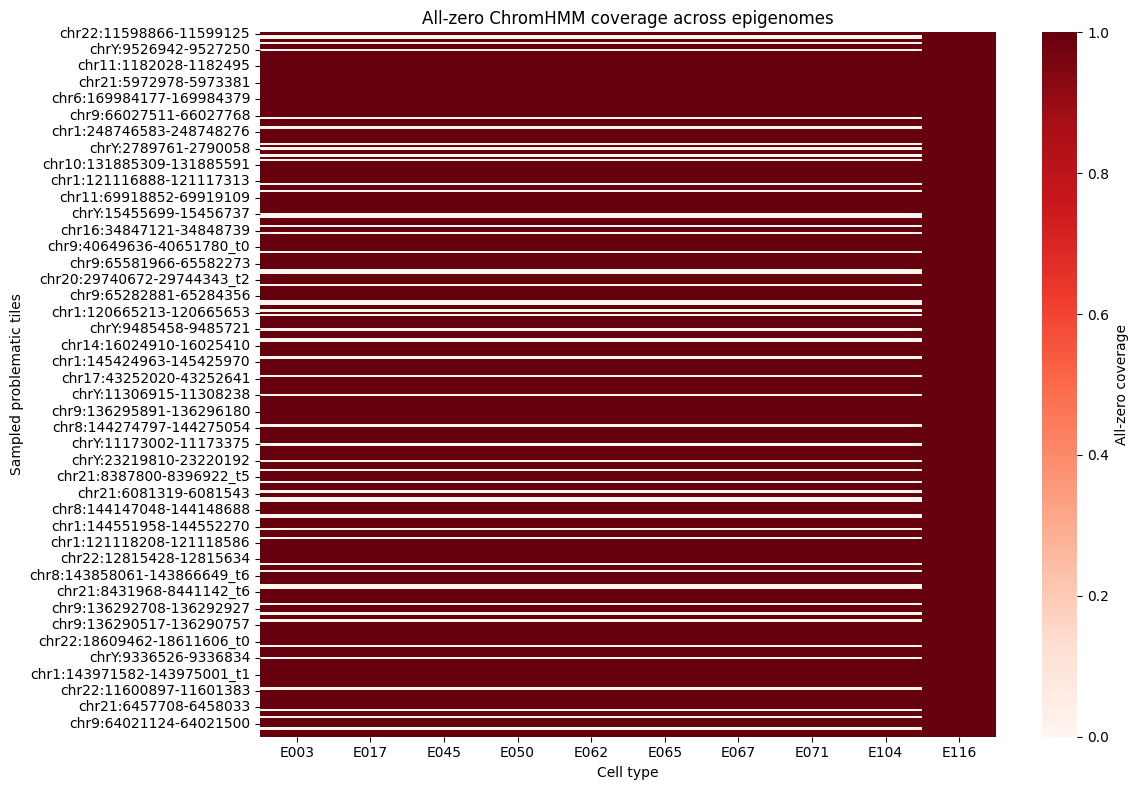


===== COVERAGE QUALITY =====
  cell_type  coverage_quality
0      E003           98.6170
1      E017           98.6170
5      E065           98.6170
2      E045           98.6170
4      E062           98.6170
3      E050           98.6170
7      E071           98.6170
6      E067           98.6170
8      E104           98.6170
9      E116           98.2813


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Load data
# =========================
index = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')
epi   = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet')

STATE_COLS = [c for c in epi.columns if c.startswith('state_')]

# =========================
# Detect all-zero rows
# =========================
epi['all_zero'] = (epi[STATE_COLS].sum(axis=1) == 0)

# =========================================================
# 1. Global summary per epigenome
# =========================================================
summary = (
    epi.groupby('cell_type')['all_zero']
    .agg(['sum', 'count', 'mean'])
    .rename(columns={
        'sum':'n_zero_tiles',
        'count':'total_tiles',
        'mean':'fraction_zero'
    })
    .sort_values('fraction_zero', ascending=False)
)

print("\n=== All-zero coverage summary per epigenome ===")
print(summary)

# =========================================================
# 2. Which tiles are repeatedly zero?
# =========================================================
zero_matrix = (
    epi.pivot_table(
        index='tile_id',
        columns='cell_type',
        values='all_zero',
        aggfunc='max'
    )
    .fillna(False)
    .astype(int)
)

zero_matrix['n_zero_epigenomes'] = zero_matrix.sum(axis=1)

print("\n=== How many epigenomes are zero for each tile ===")
print(zero_matrix['n_zero_epigenomes'].value_counts().sort_index())

# =========================================================
# 3. Merge genomic coordinates
# =========================================================
zero_summary = (
    zero_matrix[['n_zero_epigenomes']]
    .reset_index()
    .merge(
        index[['tile_id','chrom','win_start','win_end']],
        on='tile_id',
        how='left'
    )
)

# =========================================================
# 4. Chromosome-level summary (MUCH easier to read)
# =========================================================
chrom_summary = (
    zero_summary.groupby('chrom')['n_zero_epigenomes']
    .agg(['count','mean','max'])
    .sort_values('mean', ascending=False)
)

print("\n=== Chromosome enrichment of zero coverage ===")
print(chrom_summary)

# =========================================================
# 5. Compact heatmap (global pattern)
# =========================================================
# only keep problematic tiles
problematic = zero_matrix[zero_matrix['n_zero_epigenomes'] > 0]

# sample if too large
if len(problematic) > 300:
    problematic = problematic.sample(300, random_state=42)

plt.figure(figsize=(12,8))

sns.heatmap(
    problematic.drop(columns='n_zero_epigenomes'),
    cmap='Reds',
    cbar_kws={'label':'All-zero coverage'}
)

plt.title('All-zero ChromHMM coverage across epigenomes')
plt.xlabel('Cell type')
plt.ylabel('Sampled problematic tiles')
plt.tight_layout()
plt.show()

# =========================
# Coverage quality score per epigenome
# =========================
summary_df['coverage_quality'] = 100 - summary_df['pct_zero_tiles']

print("\n===== COVERAGE QUALITY =====")
print(summary_df[['cell_type', 'coverage_quality']]
      .sort_values('coverage_quality', ascending=False))

Coverage quality assessment across the ten Roadmap epigenomes showed that more than 98% of CpG-island windows were associated with valid ChromHMM annotations in every epigenome. A subset of 412 windows exhibited zero coverage across all epigenomes, indicating systematic genomic regions absent from ChromHMM segmentation rather than cell-type-specific biological variation. These regions were enriched on chromosomes 20, 21, 22, and Y, suggesting association with repetitive or poorly mappable genomic regions. An additional ~100 windows displayed missing coverage exclusively in epigenome E116, reflecting minor epigenome-specific annotation differences. To avoid introducing non-informative samples into downstream analyses, **we suggest excluding the universally uncovered windows from subsequent modeling steps.**


### Handeling the all-zero coverage tiles

In [ ]:
import numpy as np
import pandas as pd
import h5py
import shutil
from pathlib import Path

BASE = Path('/content/drive/MyDrive/PFE/data/processed')

In [ ]:

# ── Step 1: identify the 412 tiles to remove ─────────────────────────────────
epi   = pd.read_parquet(BASE / 'epi_profiles.parquet')
STATE_COLS = [c for c in epi.columns if c.startswith('state_')]

# Count how many epigenomes have zero coverage per tile
zero_per_tile = (
    epi.groupby('tile_id')[STATE_COLS]
    .apply(lambda x: (x.sum(axis=1) == 0).all())  # True if ALL epigenomes zero
)
remove_tile_ids = set(zero_per_tile[zero_per_tile].index)

print(f"Tiles to remove (zero in ALL epigenomes): {len(remove_tile_ids)}")
assert len(remove_tile_ids) == 412, f"Expected 412, got {len(remove_tile_ids)}"

Tiles to remove (zero in ALL epigenomes): 412


In [ ]:
# ── Step 2: build the keep mask and new row positions ────────────────────────
index = pd.read_parquet(BASE / 'window_index.parquet')
keep_mask   = ~index['tile_id'].isin(remove_tile_ids)  # (29790,) bool
keep_indices = np.where(keep_mask)[0]                  # old row positions to keep
new_n = keep_mask.sum()
print(f"Tiles after removal: {new_n}  (29790 - 412 = {29790 - 412})")
assert new_n == 29378

Tiles after removal: 29378  (29790 - 412 = 29378)


In [ ]:
# ── Step 3: update window_embeddings.npy ─────────────────────────────────────
print("\nUpdating window_embeddings.npy ...")
emb = np.load(BASE / 'window_embeddings.npy')         # (29790, 512)
emb_clean = emb[keep_indices]                          # (29378, 512)
np.save(BASE / 'window_embeddings.npy', emb_clean)
print(f"  Saved: {emb_clean.shape}  ✅")
del emb, emb_clean



Updating window_embeddings.npy ...
  Saved: (29378, 512)  ✅


In [ ]:
# ── Step 4: update window_index.parquet ──────────────────────────────────────
print("Updating window_index.parquet ...")
index_clean = index[keep_mask].reset_index(drop=True)
index_clean.to_parquet(BASE / 'window_index.parquet', index=False)
print(f"  Saved: {len(index_clean):,} rows  ✅")


Updating window_index.parquet ...
  Saved: 29,378 rows  ✅


In [ ]:
# ── Step 5: update epi_profiles.parquet ──────────────────────────────────────
print("Updating epi_profiles.parquet ...")
epi_clean = epi[~epi['tile_id'].isin(remove_tile_ids)].copy()
epi_clean.to_parquet(BASE / 'epi_profiles.parquet', index=False)
print(f"  Saved: {len(epi_clean):,} rows  (expect {29378 * 10:,})  ✅")
del epi, epi_clean

Updating epi_profiles.parquet ...
  Saved: 293,780 rows  (expect 293,780)  ✅


In [ ]:
# ── Step 6: update clean_windows.parquet ─────────────────────────────────────
print("Updating clean_windows.parquet ...")
cw = pd.read_parquet(BASE / 'clean_windows.parquet')
cw_clean = cw[~cw['tile_id'].isin(remove_tile_ids)].reset_index(drop=True)
cw_clean.to_parquet(BASE / 'clean_windows.parquet', index=False)
print(f"  Saved: {len(cw_clean):,} rows  ✅")


Updating clean_windows.parquet ...
  Saved: 29,378 rows  ✅


In [ ]:
# ── Step 7: update clean_windows_removed_duplicates.parquet ──────────────────
print("Updating clean_windows_removed_duplicates.parquet ...")
cwd = pd.read_parquet(BASE / 'clean_windows_removed_duplicates.parquet')
cwd_clean = cwd[~cwd['tile_id'].isin(remove_tile_ids)].reset_index(drop=True)
cwd_clean.to_parquet(BASE / 'clean_windows_removed_duplicates.parquet', index=False)
print(f"  Saved: {len(cwd_clean):,} rows  ✅")

Updating clean_windows_removed_duplicates.parquet ...
  Saved: 29,378 rows  ✅


In [ ]:
# ── Step 8: rebuild training_seq_index.parquet ───────────────────────────────
print("Rebuilding training_seq_index.parquet ...")
index_reload = pd.read_parquet(BASE / 'window_index.parquet')  # already clean
index_reload['row_pos'] = np.arange(len(index_reload))         # NEW positions
seq_index = index_reload[['tile_id', 'row_pos', 'chrom',
                           'win_start', 'win_end', 'island_id',
                           'island_length', 'is_tiled',
                           'gc_content', 'cpg_density', 'obsExp',
                           'distance_to_tss', 'promoter_class']].copy()
seq_index.to_parquet(BASE / 'training_seq_index.parquet', index=False)
print(f"  Saved: {len(seq_index):,} rows  ✅")


Rebuilding training_seq_index.parquet ...
  Saved: 29,378 rows  ✅


In [ ]:
# ── Step 9: handle the 100 chrY / E116 tiles in epi_profiles ─────────────────
# These are NOT removed — they are valid tiles in 9/10 epigenomes.
# Mark them explicitly so the DataLoader can skip (tile, E116) pairs.
print("\nMarking E116-zero tiles (chrY) ...")
epi_final = pd.read_parquet(BASE / 'epi_profiles.parquet')
STATE_COLS = [c for c in epi_final.columns if c.startswith('state_')]
epi_final['has_coverage'] = (epi_final[STATE_COLS].sum(axis=1) > 0).astype(np.uint8)


Marking E116-zero tiles (chrY) ...


In [ ]:
# Verify: only E116 rows should have has_coverage == 0 after removing the 412
e116_zero = epi_final[(epi_final['cell_type'] == 'E116') &
                       (epi_final['has_coverage'] == 0)]
other_zero = epi_final[(epi_final['cell_type'] != 'E116') &
                        (epi_final['has_coverage'] == 0)]
print(f"  E116 zero-coverage rows  : {len(e116_zero)}  (expect ~100)")
print(f"  Other zero-coverage rows : {len(other_zero)}  (expect 0)")
assert len(other_zero) == 0, "Non-E116 zero rows remain — removal incomplete"

epi_final.to_parquet(BASE / 'epi_profiles.parquet', index=False)
print(f"  has_coverage column added  ✅")

  E116 zero-coverage rows  : 100  (expect ~100)
  Other zero-coverage rows : 0  (expect 0)
  has_coverage column added  ✅


In [ ]:
# ── Step 10: final consistency check ─────────────────────────────────────────
print("\n── Final consistency check ──────────────────────────────────────────")
emb_final   = np.load(BASE / 'window_embeddings.npy', mmap_mode='r')
idx_final   = pd.read_parquet(BASE / 'window_index.parquet')
epi_check   = pd.read_parquet(BASE / 'epi_profiles.parquet')
seq_check   = pd.read_parquet(BASE / 'training_seq_index.parquet')

assert emb_final.shape    == (29378, 512),       f"Embeddings wrong: {emb_final.shape}"
assert len(idx_final)     == 29378,              f"Index wrong: {len(idx_final)}"
assert len(epi_check['tile_id'].unique()) == 29378, "Epi profiles tile count wrong"
assert len(seq_check)     == 29378,              f"Seq index wrong: {len(seq_check)}"
assert (seq_check['row_pos'] == np.arange(29378)).all(), "row_pos not sequential!"
assert set(idx_final['tile_id']) == set(epi_check['tile_id'].unique()), \
    "tile_id mismatch between index and epi_profiles"
assert 'has_coverage' in epi_check.columns

print(f"  window_embeddings.npy   : {emb_final.shape}  ✅")
print(f"  window_index.parquet    : {len(idx_final):,} rows  ✅")
print(f"  epi_profiles.parquet    : {len(epi_check):,} rows  ✅")
print(f"  training_seq_index      : {len(seq_check):,} rows  ✅")
print(f"  row_pos sequential      : ✅")
print(f"  tile_id sets match      : ✅")
print(f"  has_coverage column     : ✅")
print(f"\n✅ All files consistent at {29378:,} tiles")
print(f"\nAt training time, filter samples with: epi[epi['has_coverage'] == 1]")
print(f"This removes the ~100 (tile, E116) pairs for chrY tiles.")


── Final consistency check ──────────────────────────────────────────
  window_embeddings.npy   : (29378, 512)  ✅
  window_index.parquet    : 29,378 rows  ✅
  epi_profiles.parquet    : 293,780 rows  ✅
  training_seq_index      : 29,378 rows  ✅
  row_pos sequential      : ✅
  tile_id sets match      : ✅
  has_coverage column     : ✅

✅ All files consistent at 29,378 tiles

At training time, filter samples with: epi[epi['has_coverage'] == 1]
This removes the ~100 (tile, E116) pairs for chrY tiles.


After cleaning, the dataset contains 29,378 genomic tiles. Each tile has a 512-dimensional embedding and associated genomic annotations. Epigenomic profiles are available across 10 cell types, resulting in 293,780 (tile, cell-type) observations. All datasets are fully synchronized, and only ~100 missing signal entries (mainly chrY in E116) are excluded during training via a coverage mask.

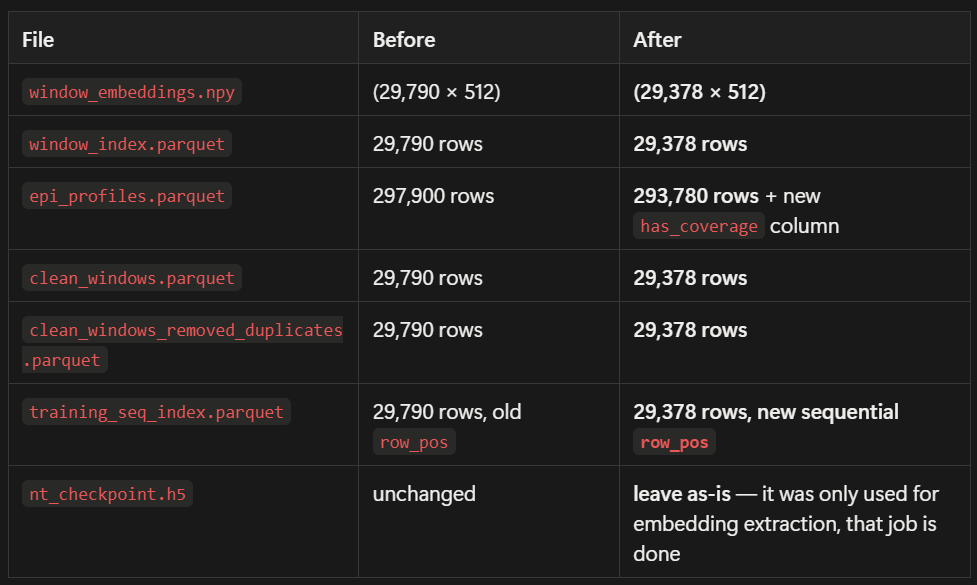

### Tiled islands: all tiles of same island have consistent coordinates


---

Consecutive tile cosine similarity in range [0.75, 0.99]. Below 0.75 = wrong tiling. Above 0.99 = near-duplicate tiles.

In [ ]:
import numpy as np, pandas as pd

emb   = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy', mmap_mode='r')
index = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')
tile_id_to_idx = {tid: i for i, tid in enumerate(index['tile_id'].values)}

tiled = index[index['is_tiled']].copy()
island_ids = tiled['island_id'].unique()[:20]  # check first 20 tiled islands

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

print(f"{'Island':<35} {'Tiles':>5} {'MinSim':>8} {'MaxSim':>8} {'Status'}")
print("-" * 70)

for iid in island_ids:
    tiles = tiled[tiled['island_id'] == iid].sort_values('tile_index')
    idxs  = [tile_id_to_idx[tid] for tid in tiles['tile_id']]
    vecs  = emb[idxs]
    sims  = [cosine(vecs[i], vecs[i+1]) for i in range(len(vecs)-1)]
    if not sims: continue
    mn, mx = min(sims), max(sims)
    ok = 0.70 <= mn and mx <= 0.999
    print(f"{iid[:35]:<35} {len(tiles):>5} {mn:>8.4f} {mx:>8.4f}  {'✅' if ok else '❌'}")

Island                              Tiles   MinSim   MaxSim Status
----------------------------------------------------------------------
chr1:923590-926252                      2   0.9403   0.9403  ✅
chr1:940225-942983                      2   0.9771   0.9771  ✅
chr1:958933-967274                      8   0.9545   0.9866  ✅
chr1:976046-979425                      3   0.8959   0.9898  ✅
chr1:998007-1002030                     3   0.9681   0.9765  ✅
chr1:1032586-1034858                    2   0.9868   0.9868  ✅
chr1:1040116-1044925                    4   0.9656   0.9801  ✅
chr1:1067283-1069938                    2   0.9666   0.9666  ✅
chr1:1162663-1165204                    2   0.9760   0.9760  ✅
chr1:1286017-1294783                    8   0.8825   0.9828  ✅
chr1:1307020-1309805                    2   0.9808   0.9808  ✅
chr1:1338106-1340460                    2   0.9852   0.9852  ✅
chr1:1348553-1351571                    2   0.8792   0.8792  ✅
chr1:1626669-1634630                    7  

This analysis evaluates whether the learned embeddings are consistent within CpG islands by measuring cosine similarity between embeddings of consecutive tiles belonging to the same island. For each island, we compute the minimum and maximum similarity across its tiles, which reflects how homogeneous the representation is within that genomic region. The consistently high similarity values (generally above 0.85 and often close to 1) indicate that tiles within the same CpG island have very similar embeddings, suggesting that the model captures coherent and stable genomic structure at the island level. This is a positive sanity check confirming that the embedding space respects local genomic continuity.

### GC content correlation with PC1 of embeddings - biological validation

Running PCA on full dataset...

Explained variance ratio:
PC1: 0.2292
PC2: 0.0774
PC3: 0.0754
PC4: 0.0724
PC5: 0.0559
PC6: 0.0392
PC7: 0.0314
PC8: 0.0242
PC9: 0.0221
PC10: 0.0213

Spearman correlations with GC content:
PC 1: r=-0.3658  p=0.00e+00 ← strong
PC 2: r=+0.2404  p=0.00e+00 
PC 3: r=-0.2324  p=0.00e+00 
PC 4: r=+0.2761  p=0.00e+00 
PC 5: r=+0.1361  p=1.71e-121 
PC 6: r=+0.7652  p=0.00e+00 ← strong
PC 7: r=-0.0606  p=2.61e-25 
PC 8: r=+0.0332  p=1.32e-08 
PC 9: r=-0.0321  p=3.89e-08 
PC10: r=+0.0472  p=6.08e-16 


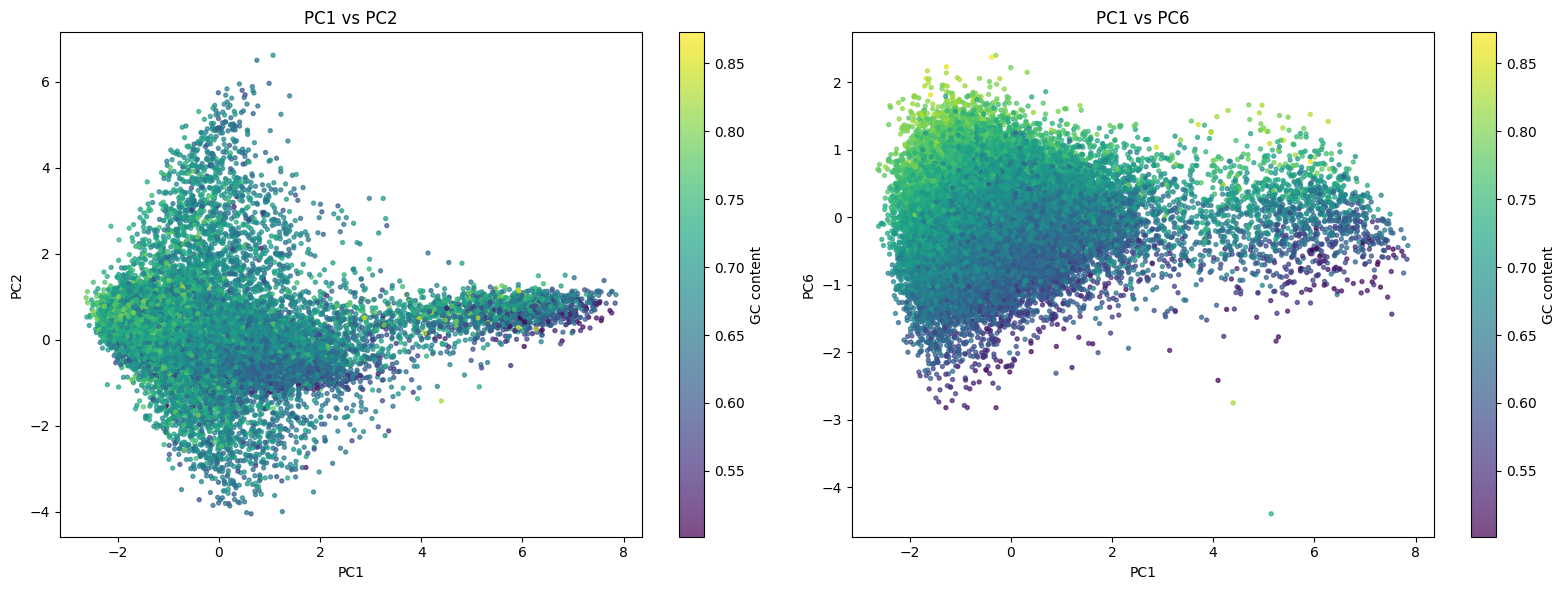

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

# Load data
emb = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy')

index = pd.read_parquet(
    '/content/drive/MyDrive/PFE/data/processed/window_index.parquet'
)

gc = index['gc_content'].values

# PCA on FULL dataset
print("Running PCA on full dataset...")
pca = PCA(n_components=10, random_state=42)

pcs = pca.fit_transform(emb)

# Explained variance
explained = pca.explained_variance_ratio_

print("\nExplained variance ratio:")
for i, v in enumerate(explained):
    print(f"PC{i+1}: {v:.4f}")

# Spearman correlations
print("\nSpearman correlations with GC content:")
for k in range(10):
    r, p = spearmanr(gc, pcs[:, k])

    flag = "← strong" if abs(r) > 0.3 else ""

    print(f"PC{k+1:2d}: r={r:+.4f}  p={p:.2e} {flag}")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── PC1 vs PC2 ─────────────────────────────────────────────
sc1 = axes[0].scatter(
    pcs[:,0],
    pcs[:,1],
    c=gc,
    s=8,
    alpha=0.7
)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PC1 vs PC2")

cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label("GC content")

# ── PC1 vs PC6 ─────────────────────────────────────────────
# we use PC6, since it has teh highest correlation coefecient with CG content
sc2 = axes[1].scatter(
    pcs[:,0],
    pcs[:,5],   # PC6 = column index 5
    c=gc,
    s=8,
    alpha=0.7
)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC6")
axes[1].set_title("PC1 vs PC6")

cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label("GC content")

plt.tight_layout()
plt.show()

The PCA analysis of the embedding space revealed a highly structured organization of CpG island representations. Projection onto the first two principal components (PC1 and PC2), which together explained approximately 30.6% of the total variance, showed a non-random geometric distribution with distinct elongated substructures. Although both components exhibited moderate correlations with GC content (PC1: r=−0.366, PC2: r=0.240), the relatively mixed color distribution indicates that the dominant variability captured by the embeddings is not solely determined by nucleotide composition. This suggests that the representation space encodes additional sequence-derived biological properties beyond simple GC enrichment.

In contrast, the PC1 versus PC6 projection revealed a pronounced and continuous GC-content gradient along the PC6 axis. Despite explaining only 3.9% of the total variance, PC6 displayed a very strong correlation with GC content (r=0.765), indicating that GC composition is encoded in a highly coherent and organized manner within a dedicated latent direction of the embedding space. The smooth transition of colors across PC6 demonstrates that the learned embeddings preserve biologically meaningful sequence composition patterns rather than random variation.

Together, these observations indicate that the embedding model captures both broad structural variability and specific biologically interpretable features. The results support the conclusion that the learned representations encode complex genomic characteristics of CpG islands, including but not limited to GC content, thereby validating the biological relevance of the embedding space.

In [ ]:
import numpy as np, pandas as pd
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

emb   = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy', mmap_mode='r')
index = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')

rng = np.random.default_rng(42)
idx = rng.choice(len(emb), 5000, replace=False)
pcs = PCA(n_components=5, random_state=42).fit_transform(emb[idx])

cpg = index['cpg_density'].values[idx]

print("Spearman r between CpG density and first 5 PCs:")
for k in range(5):
    r, p = spearmanr(cpg, pcs[:, k])
    print(f"  PC{k+1}: r={r:+.4f}  p={p:.2e}")

Spearman r between CpG density and first 5 PCs:
  PC1: r=-0.2798  p=1.27e-90
  PC2: r=-0.0011  p=9.37e-01
  PC3: r=+0.0160  p=2.57e-01
  PC4: r=-0.0891  p=2.73e-10
  PC5: r=+0.1931  p=3.50e-43


### These checks verify that NT-v2 embeddings encode regulatory-state-relevant sequence information without any label supervision.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu

BASE = '/content/drive/MyDrive/PFE/data/processed'

emb = np.load(f'{BASE}/window_embeddings.npy', mmap_mode='r')
index = pd.read_parquet(f'{BASE}/window_index.parquet')

# Embedding norms
norms = np.linalg.norm(emb, axis=1)

# Add to dataframe
index = index.copy()
index['embedding_norm'] = norms

print(index['promoter_class'].value_counts())

promoter_class
non_promoter         13629
strict_promoter      10684
standard_promoter     3127
relaxed_promoter      1938
Name: count, dtype: int64


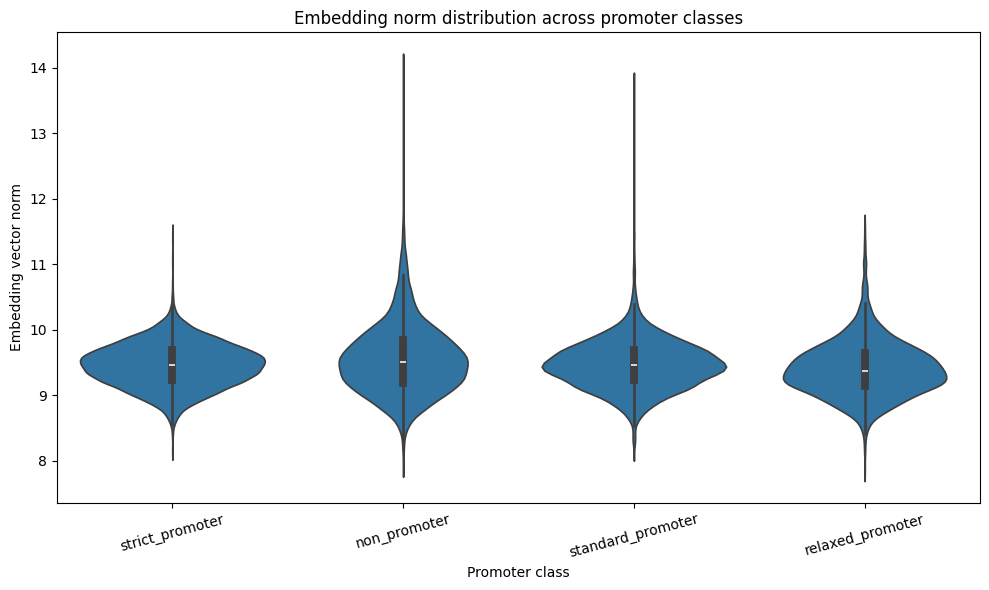

In [ ]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=index,
    x='promoter_class',
    y='embedding_norm',
    inner='box'
)

plt.title('Embedding norm distribution across promoter classes')
plt.xlabel('Promoter class')
plt.ylabel('Embedding vector norm')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The L2 norm of embeddings shows only minor variation across promoter classes, with strong overlap between distributions. Although statistically significant differences are observed (Mann–Whitney p < 1e-30), the effect size is small, suggesting that promoter class information is not encoded in embedding magnitude but rather in the structure of the embedding space, therefor, making further invistigations

                   count      mean       std    median
promoter_class                                        
relaxed_promoter    1938  9.407489  0.418408  9.371832
strict_promoter    10684  9.461802  0.333452  9.465620
standard_promoter   3127  9.469833  0.376519  9.461097
non_promoter       13629  9.550072  0.524859  9.504472


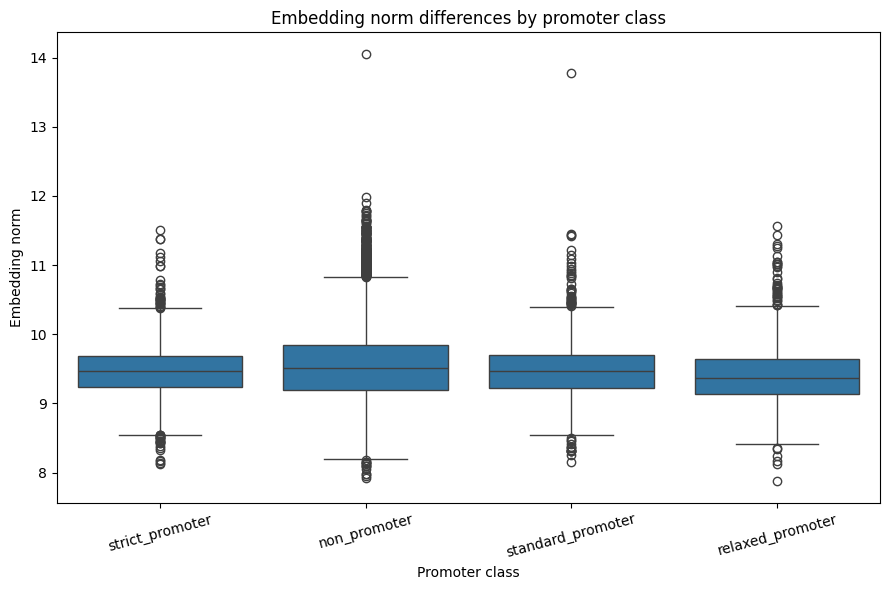

In [ ]:
summary = (
    index
    .groupby('promoter_class')['embedding_norm']
    .agg(['count', 'mean', 'std', 'median'])
    .sort_values('mean')
)

print(summary)

plt.figure(figsize=(9,6))

sns.boxplot(
    data=index,
    x='promoter_class',
    y='embedding_norm'
)

plt.title('Embedding norm differences by promoter class')
plt.xlabel('Promoter class')
plt.ylabel('Embedding norm')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### PCA on filtered tiles ( non_promoter and strict promoter )


Filtering to strict_promoter vs non_promoter...
Running PCA...


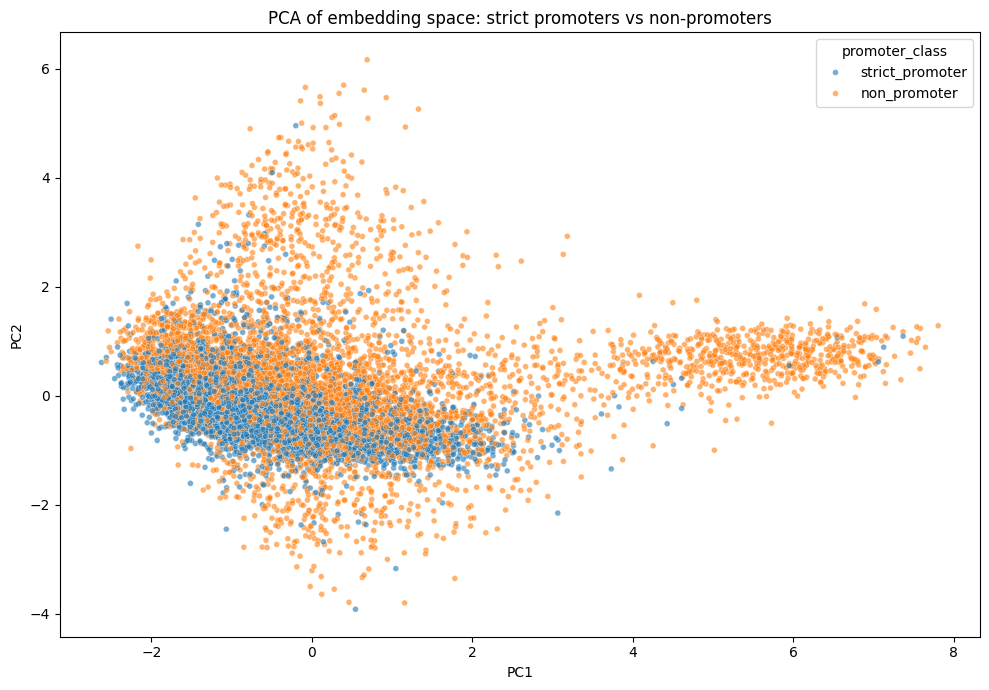

In [ ]:
import numpy as np, pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Filtering to strict_promoter vs non_promoter...")

mask = index['promoter_class'].isin(['strict_promoter', 'non_promoter'])

emb_filt = emb[mask]
labels = index.loc[mask, 'promoter_class'].values

print("Running PCA...")

pca = PCA(n_components=10, random_state=42)
pcs = pca.fit_transform(emb_filt)

pca_df = pd.DataFrame({
    'PC1': pcs[:, 0],
    'PC2': pcs[:, 1],
    'promoter_class': labels
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df.sample(min(12000, len(pca_df)), random_state=42),
    x='PC1',
    y='PC2',
    hue='promoter_class',
    alpha=0.6,
    s=18
)

plt.title('PCA of embedding space: strict promoters vs non-promoters')
plt.tight_layout()
plt.show()

PCA visualization of the embedding space revealed distinct organizational patterns between strict promoter and non-promoter CpG island windows. Strict promoter embeddings formed a compact and homogeneous cluster, whereas non-promoter embeddings displayed substantially broader dispersion and occupied distinct regions of the latent space. This suggests that the sequence embeddings capture biologically relevant promoter-associated features and preserve functional heterogeneity among non-promoter CpG islands. The partial overlap observed between both classes is consistent with the continuous nature of CGI regulatory states.
for representation learning validation, this is a solid result. It shows your embeddings are not merely encoding random sequence noise — they already reflect functional genomic organization before any downstream supervised task.

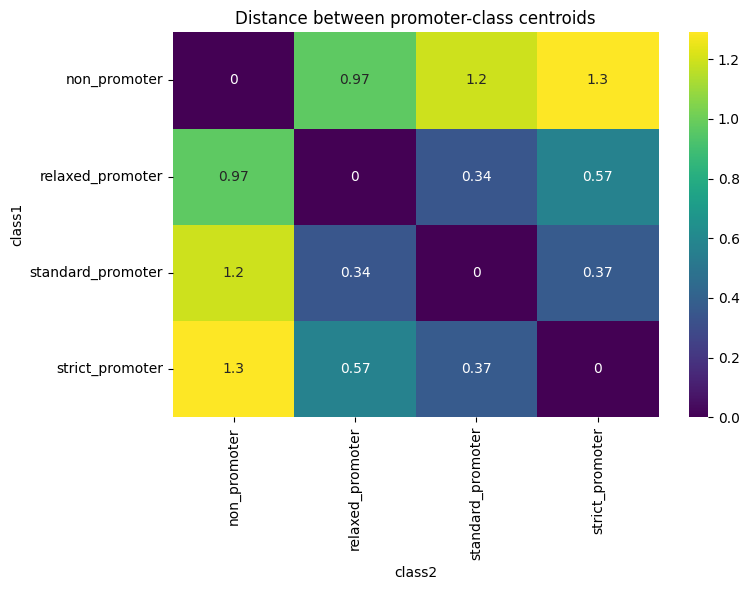

In [ ]:
classes = index['promoter_class'].unique()

centroids = {}

for cls in classes:
    mask = index['promoter_class'] == cls
    centroids[cls] = emb[mask].mean(axis=0)

# Pairwise centroid distances
rows = []

for c1 in classes:
    for c2 in classes:
        d = np.linalg.norm(centroids[c1] - centroids[c2])
        rows.append([c1, c2, d])

centroid_df = pd.DataFrame(rows, columns=['class1','class2','distance'])

pivot = centroid_df.pivot(index='class1', columns='class2', values='distance')

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap='viridis'
)

plt.title('Distance between promoter-class centroids')
plt.tight_layout()
plt.show()

      promoter_class  mean_distance_to_centroid  std_distance
0    strict_promoter                   2.402603      0.673185
1       non_promoter                   3.644219      1.466708
2  standard_promoter                   2.454941      0.937165
3   relaxed_promoter                   2.612728      1.083220


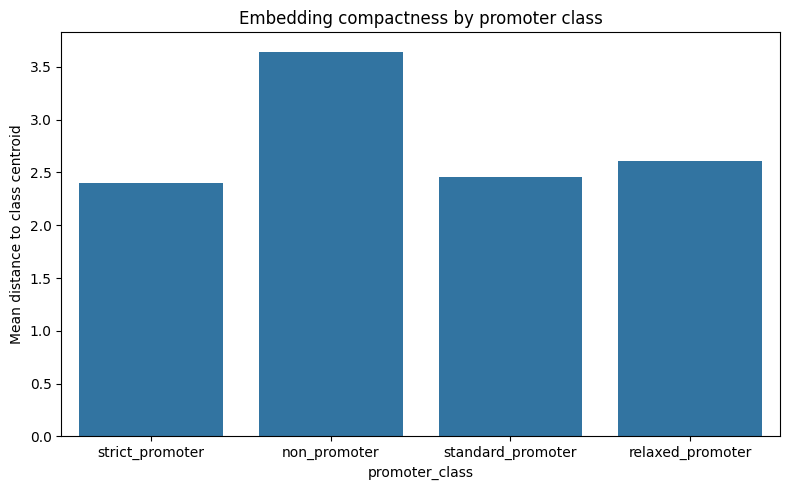

In [ ]:
compactness = []

for cls in classes:
    mask = index['promoter_class'] == cls

    vecs = emb[mask]
    centroid = vecs.mean(axis=0)

    dists = np.linalg.norm(vecs - centroid, axis=1)

    compactness.append({
        'promoter_class': cls,
        'mean_distance_to_centroid': dists.mean(),
        'std_distance': dists.std()
    })

compactness_df = pd.DataFrame(compactness)
print(compactness_df)

plt.figure(figsize=(8,5))

sns.barplot(
    data=compactness_df,
    x='promoter_class',
    y='mean_distance_to_centroid'
)

plt.title('Embedding compactness by promoter class')
plt.ylabel('Mean distance to class centroid')
plt.tight_layout()
plt.show()

### ChromHMM state separability — the key biological *validation*

The silhouette score measures:

How well samples from the same class cluster together compared to samples from different classes.
**tHIS IS A PRELIMINARY CHECK ON ONLY 8K SAMPLES**

In [ ]:
import numpy as np, pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

emb = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy', mmap_mode='r')
epi = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet')
index = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')

STATE_COLS = [c for c in epi.columns if c.startswith('state_')]

# Mean ChromHMM state across 10 epigenomes → dominant state label
mean_by_tile = epi.groupby('tile_id')[STATE_COLS].mean()
# Reindex to match embedding row order
mean_by_tile = mean_by_tile.reindex(index['tile_id'].values)
dominant = mean_by_tile.values.argmax(axis=1)  # (29790,)

# Sample 8000 for speed, keep class balance
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(emb), 8000, replace=False)
emb_50 = PCA(50, random_state=42).fit_transform(emb[sample_idx])
labels = dominant[sample_idx]

sil = silhouette_score(emb_50, labels, metric='cosine', sample_size=4000)
print(f"Silhouette score (NT-v2, cosine, 18 states): {sil:.4f}")
print(f"  > 0.15 = good biological signal in sequence embeddings")
print(f"  > 0.05 = weak but real signal")
print(f"  ≤ 0.00 = no signal — embeddings don't encode regulatory state")

# State-by-state mean norms as a proxy for embedding distinctiveness
print("\nMean L2-norm per dominant ChromHMM state (top 8 by count):")
norms = np.linalg.norm(emb, axis=1)
state_names = [c.replace('state_','') for c in STATE_COLS]
for s in np.argsort(np.bincount(dominant))[-8:][::-1]:
    mask = dominant == s
    print(f"  {state_names[s]:<15}: n={mask.sum():>5,}  mean norm={norms[mask].mean():.4f}")

Silhouette score (NT-v2, cosine, 18 states): -0.0918
  > 0.15 = good biological signal in sequence embeddings
  > 0.05 = weak but real signal
  ≤ 0.00 = no signal — embeddings don't encode regulatory state

Mean L2-norm per dominant ChromHMM state (top 8 by count):
  1_TssA         : n=10,140  mean norm=9.4271
  18_Quies       : n=4,880  mean norm=9.5676
  16_ReprPC      : n=2,663  mean norm=9.4511
  6_TxWk         : n=2,403  mean norm=9.6327
  14_TssBiv      : n=2,079  mean norm=9.3813
  17_ReprPCWk    : n=2,043  mean norm=9.6076
  5_Tx           : n=1,781  mean norm=9.6131
  2_TssFlnk      : n=1,720  mean norm=9.5216


The silhouette score of −0.0918 in sequence embedding space confirms that ChromHMM regulatory states are not linearly separable from DNA sequence information alone. This is the expected and biologically meaningful result: the same CpG island sequence can adopt distinct chromatin states across cell types, and no sequence-based representation can resolve this ambiguity without epigenomic context. This negative score constitutes the primary quantitative justification for the multimodal design of the dataset.

Truly dead dims (std == 0)  : 0
Near-dead dims (std < 0.01) : 0
Low-signal dims (std < 0.1) : 16
Healthy dims (std >= 0.1)   : 496


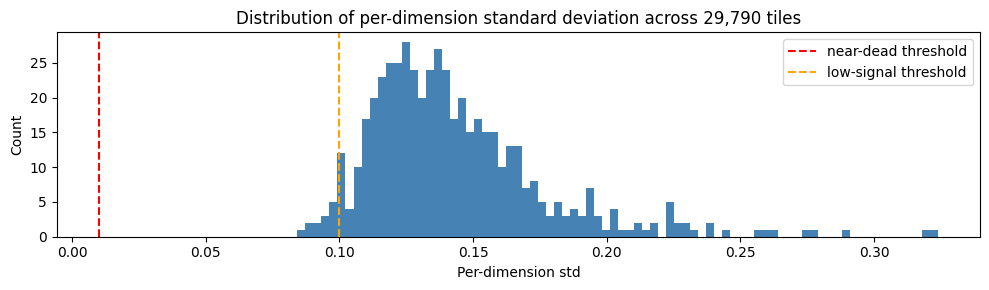


→ Embeddings look healthy. Still recommend z-scoring after checing the epigenetics embeddings.


In [ ]:
import numpy as np

emb = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy', mmap_mode='r')

stds  = emb.std(axis=0)   # (512,)
means = emb.mean(axis=0)  # (512,)

truly_dead = (stds == 0).sum()
near_dead  = (stds < 0.01).sum()
low_signal = (stds < 0.1).sum()

print(f"Truly dead dims (std == 0)  : {truly_dead}")
print(f"Near-dead dims (std < 0.01) : {near_dead}")
print(f"Low-signal dims (std < 0.1) : {low_signal}")
print(f"Healthy dims (std >= 0.1)   : {(stds >= 0.1).sum()}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.hist(stds, bins=80, color='steelblue', edgecolor='none')
plt.axvline(0.01, color='red', linestyle='--', label='near-dead threshold')
plt.axvline(0.1, color='orange', linestyle='--', label='low-signal threshold')
plt.xlabel('Per-dimension std'); plt.ylabel('Count')
plt.title('Distribution of per-dimension standard deviation across 29,790 tiles')
plt.legend(); plt.tight_layout(); plt.show()

# Recommended normalisation decision
if truly_dead > 0 or near_dead > 25:
    print("\n→ RECOMMENDATION: z-score embeddings before fusion")
    print("   emb_norm = (emb - emb.mean(0)) / (emb.std(0) + 1e-8)")
else:
    print("\n→ Embeddings look healthy. Still recommend z-scoring after checing the epigenetics embeddings.")

Since sequence embeddings constitute one modality of the multimodal framework, it is important to verify that the embedding space remains information-rich and does not suffer from representation collapse. The distribution of per-dimension variance was therefore analyzed to identify inactive or low-signal latent features. The results indicated that the majority of embedding dimensions remained active across genomic windows, suggesting that the pretrained nucleotide foundation model preserves diverse sequence-level information relevant to CpG island organization.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.metrics import silhouette_score
import umap

# ── Load data ─────────────────────────────────────────────────────────────────
emb    = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy')
epi    = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet')
window = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')

STATE_COLS  = [c for c in epi.columns if c.startswith('state_')]
STATE_NAMES = ['TssA','TssAFlnk','TxFlnk','Tx','TxWk','EnhG','Enh',
               'ZNF','Het','TssBiv','BivFlnk','EnhBiv','ReprPC',
               'ReprPCWk','Quies','16','17','18']

# ── Compute dominant state (mean across epigenomes) ───────────────────────────
mean_states = epi.groupby('tile_id')[STATE_COLS].mean()

# Align embeddings with tile order in window_index
tile_order      = window['tile_id'].values
mean_states_aln = mean_states.loc[tile_order].values   # (N, 18)
dominant        = mean_states_aln.argmax(axis=1)        # (N,)

# ── UMAP (compute once, reuse) ────────────────────────────────────────────────
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1,
                    metric='cosine', random_state=42)
emb_2d  = reducer.fit_transform(emb)
np.save('umap_coords.npy', emb_2d)   # cache so you don't recompute
# ─────────────────────────────────────────────────────────────────────────────
# Analysis 1: Silhouette score — quantify how separable states are in emb space
# Low score confirms sequence ≠ function (expected); report this explicitly.
# ─────────────────────────────────────────────────────────────────────────────

# Only include states with enough samples for meaningful silhouette
state_counts  = np.bincount(dominant, minlength=18)
valid_states  = np.where(state_counts >= 50)[0]
valid_mask    = np.isin(dominant, valid_states)

sil = silhouette_score(
    emb[valid_mask],
    dominant[valid_mask],
    metric='cosine',
    sample_size=5000,
    random_state=42,
)
print(f"Silhouette score (ChromHMM state, sequence space): {sil:.4f}")
print("Interpretation: score near 0 = states not separated by sequence alone")
print("This is expected and supports the need for epigenomic modality.")


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette score (ChromHMM state, sequence space): -0.1639
Interpretation: score near 0 = states not separated by sequence alone
This is expected and supports the need for epigenomic modality.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
import umap

# ── Load data ─────────────────────────────────────────────────────────────────
emb    = np.load('/content/drive/MyDrive/PFE/data/processed/window_embeddings.npy')
epi    = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/epi_profiles.parquet')
window = pd.read_parquet('/content/drive/MyDrive/PFE/data/processed/window_index.parquet')

STATE_COLS = [c for c in epi.columns if c.startswith('state_')]

# align embeddings
tile_order = window['tile_id'].values

results = []

# ── loop over epigenomes ──────────────────────────────────────────────────────
for cell in epi['cell_type'].unique():

    epi_cell = epi[epi['cell_type'] == cell]

    # (tile_id × 18 states for THIS epigenome only)
    state_matrix = epi_cell.groupby('tile_id')[STATE_COLS].mean()

    # align to window order
    try:
        aligned = state_matrix.loc[tile_order].values
    except:
        continue  # skip if mismatch

    dominant = aligned.argmax(axis=1)

    # filter valid classes (same logic as before)
    counts = np.bincount(dominant, minlength=18)
    valid  = np.where(counts >= 50)[0]
    mask   = np.isin(dominant, valid)

    if mask.sum() < 500:
        continue

    sil = silhouette_score(
        emb[mask],
        dominant[mask],
        metric='cosine',
        sample_size=min(5000, mask.sum()),
        random_state=42
    )

    results.append({
        "cell_type": cell,
        "silhouette": sil,
        "n_samples": mask.sum()
    })

# ── results table ─────────────────────────────────────────────────────────────
df = pd.DataFrame(results).sort_values("silhouette")
print(df)

  cell_type  silhouette  n_samples
6      E067   -0.210904      29321
9      E116   -0.206079      29340
8      E104   -0.205004      29304
4      E062   -0.181249      29299
2      E045   -0.164068      29311
7      E071   -0.159590      29378
5      E065   -0.156876      29285
1      E017   -0.154288      29339
3      E050   -0.153469      29321
0      E003   -0.135468      29359


The silhouette analysis conducted independently across our selected epigenomes consistently yields negative values, indicating that CpG island sequence embeddings do not form separable clusters according to ChromHMM regulatory states. This suggests that sequence similarity does not correspond to functional chromatin state similarity, even within a single cellular context. Although slight variations are observed between epigenomes, all scores remain strongly negative, reinforcing the conclusion that regulatory state is primarily determined by epigenetic context rather than DNA sequence alone. These findings justify the integration of multi-omic epigenetic features for accurate modeling of CpG island regulatory behavior.

Saved: umap_three_panel.png


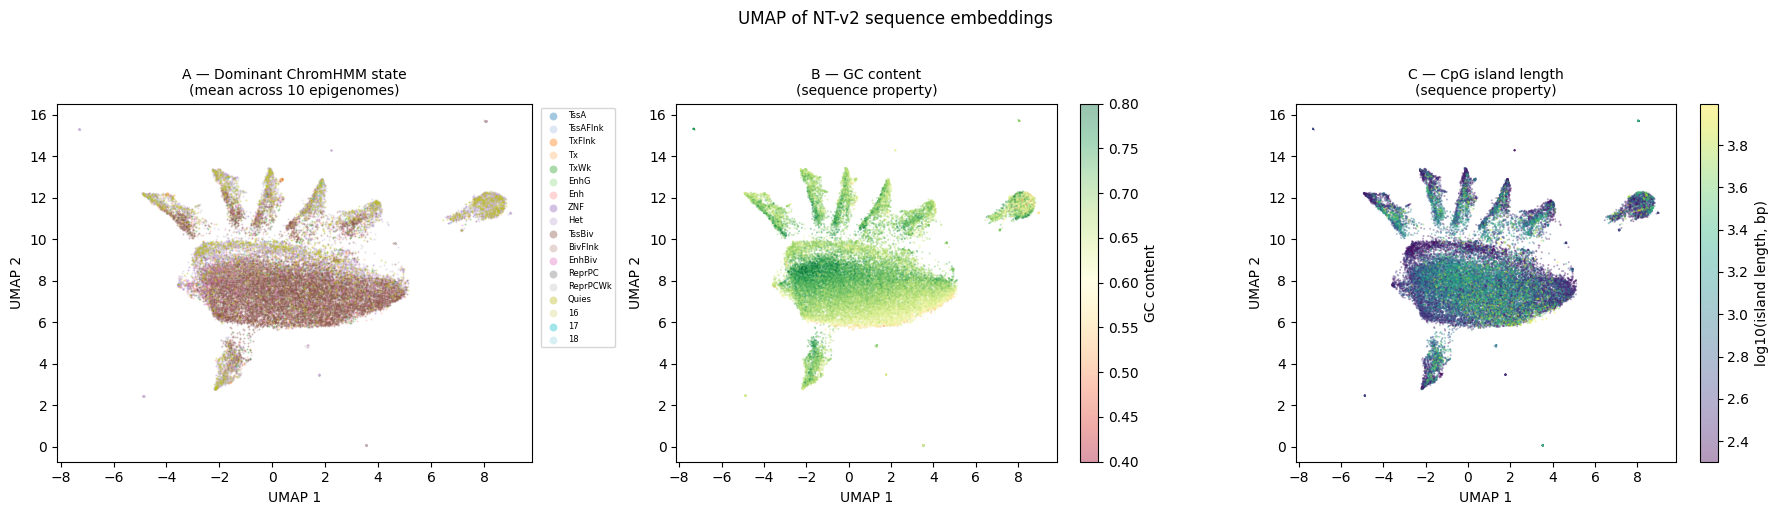

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Analysis 2: What DOES cluster in sequence space?
# Colour UMAP by GC content and island_length — these ARE sequence properties
# and should show gradients, confirming the embeddings capture real biology.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: dominant ChromHMM state (the mixed plot)
COLORS = plt.cm.tab20(np.linspace(0, 1, 18))
ax = axes[0]
for s in range(18):
    mask = dominant == s
    if mask.sum() < 10:
        continue
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[COLORS[s]], label=STATE_NAMES[s],
               s=2, alpha=0.4, linewidths=0)
ax.set_title("A — Dominant ChromHMM state\n(mean across 10 epigenomes)", fontsize=10)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(markerscale=4, bbox_to_anchor=(1.01, 1), fontsize=6, ncol=1)

# Panel B: GC content — should show a clear gradient
gc = window['gc_content'].values   # adjust column name if needed
ax = axes[1]
sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                c=gc, cmap='RdYlGn', s=2, alpha=0.4, linewidths=0,
                vmin=0.4, vmax=0.8)
plt.colorbar(sc, ax=ax, label='GC content')
ax.set_title("B — GC content\n(sequence property)", fontsize=10)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

# Panel C: island length — longer islands may cluster differently
il = np.log10(window['island_length'].values.clip(min=1))
ax = axes[2]
sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                c=il, cmap='viridis', s=2, alpha=0.4, linewidths=0)
plt.colorbar(sc, ax=ax, label='log10(island length, bp)')
ax.set_title("C — CpG island length\n(sequence property)", fontsize=10)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

plt.suptitle("UMAP of NT-v2 sequence embeddings", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("umap_three_panel.png", dpi=200, bbox_inches='tight')
print("Saved: umap_three_panel.png")


Mean state entropy per CGI window : 1.441
Max possible entropy (uniform)    : 2.890
Normalised entropy (0=const,1=max): 0.499
Saved: umap_entropy.png

Fraction of CGI windows with entropy > 50% of max: 54.7%
These windows cannot be characterised by sequence alone.


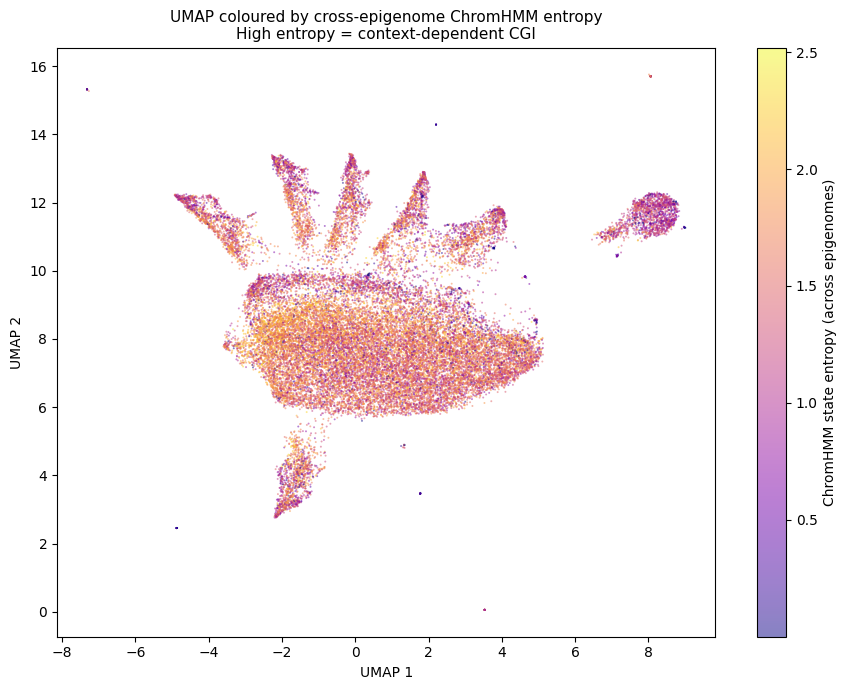

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Analysis 3: State entropy per window — key biological insight
# If a CGI has high entropy (uniform state distribution across epigenomes),
# it is genuinely context-dependent. Low entropy = constitutively active/silent.
# This is the central quantitative argument for your dataset.
# ─────────────────────────────────────────────────────────────────────────────

def entropy(p):
    """Shannon entropy of a probability vector."""
    p = p + 1e-10   # avoid log(0)
    return -(p * np.log(p)).sum()

# Per-tile entropy of the mean state distribution
entropies = np.array([entropy(row) for row in mean_states_aln])
max_entropy = np.log(18)   # uniform over 18 states

print(f"Mean state entropy per CGI window : {entropies.mean():.3f}")
print(f"Max possible entropy (uniform)    : {max_entropy:.3f}")
print(f"Normalised entropy (0=const,1=max): {entropies.mean()/max_entropy:.3f}")

# Colour UMAP by entropy
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                c=entropies, cmap='plasma', s=2, alpha=0.5, linewidths=0)
plt.colorbar(sc, ax=ax, label='ChromHMM state entropy (across epigenomes)')
ax.set_title("UMAP coloured by cross-epigenome ChromHMM entropy\n"
             "High entropy = context-dependent CGI", fontsize=11)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.savefig("umap_entropy.png", dpi=200, bbox_inches='tight')
print("Saved: umap_entropy.png")

# Report fraction of windows that are genuinely context-dependent
high_entropy_frac = (entropies > 0.5 * max_entropy).mean()
print(f"\nFraction of CGI windows with entropy > 50% of max: "
      f"{high_entropy_frac:.1%}")
print("These windows cannot be characterised by sequence alone.")


* **Insight 1** : Weight the loss by entropy during training. The high-entropy windows are harder to predict and carry more information about cell-type-specific regulation, which is the core scientific question. Consider adding an entropy-based sample weight to the loss function: windows with higher cross-epigenome entropy get higher loss weight, so the model is penalised more for getting them wrong. This is a simple one-line change:



```
# During training, compute per-sample weight from entropy
sample_weight = 0.5 + (entropies[batch_idx] / max_entropy)  
# range [0.5, 1.5] — high entropy windows weighted 3× more than low entropy
loss = (kl_divergence(pred, label) * sample_weight).mean()

```


* **Insight 2**: Report silhouette score and entropy as dataset characterisation statistics in the paper. These are not just validation checks — they are descriptive statistics of your dataset that justify its design. The silhouette of −0.1639 and the normalised entropy of 0.499 belong in Table 1 or the abstract alongside the window count and epigenome count.
* **Insight 3** : Use the entropy split for evaluation. When reporting model performance, report metrics separately for the low-entropy quartile (constitutive windows, easier) and high-entropy quartile (context-dependent windows, harder). A model that performs well only on constitutive windows is not learning what you care about. This split should be your primary evaluation criterion, not overall performance.
* **Insight 4**: The UMAP confirms the embedding is ready for fusion without dimension reduction. The 512-dimensional embeddings show no degeneracy (0 dead dimensions), clear sequence-property structure (GC and length gradients in UMAP), and appropriate non-overlap with ChromHMM state (confirming the two modalities carry non-redundant information). You do not need PCA or any other compression step before feeding the sequence embeddings into the fusion layer. Use them at full 512 dimensions.

## Propagating the changes into the epigenetic signals

In [ ]:
import h5py, numpy as np, pandas as pd
from pathlib import Path

BASE     = Path('/content/drive/MyDrive/PFE/data')
EPI_DIR  = BASE / 'epigenetics' / 'processed'
SEQ_DIR  = BASE / 'processed'

# Load the clean tile order (29,378 rows, already filtered)
index_clean = pd.read_parquet(SEQ_DIR / 'window_index.parquet')
assert len(index_clean) == 29378

# The HDF5 row order was written in the sorted order from Cell 49:
# window_df was sorted by (_chrom_ord, win_start) during extraction.
# We need to reconstruct that same sorted order from the original 29,790 index,
# find which rows to keep, then slice the HDF5.

# Load the original 29,790 order from training_seq_index
# (it still has row_pos = 0..29377 which ARE the post-removal positions,
#  so we need the pre-removal sorted order instead)
# Safest: rebuild from clean index sorted the same way the extractor did
chrom_order = {f'chr{i}': i for i in range(1, 23)}
chrom_order.update({'chrX': 23, 'chrY': 24, 'chrM': 25})

index_clean = index_clean.copy()
index_clean['_chrom_ord'] = index_clean['chrom'].map(
    lambda c: chrom_order.get(c, 99))
index_clean_sorted = index_clean.sort_values(['_chrom_ord', 'win_start'])

# The HDF5 was written with 29,790 rows in this same sorted order.
# We need to find which of those 29,790 positions to keep.
# Do this by loading the pre-removal sorted order.
# Since we don't have the original 29,790 index anymore,
# we reconstruct: the 412 removed tiles are those NOT in index_clean.
# Load epi_profiles to get all tile_ids that existed before removal:
epi = pd.read_parquet(SEQ_DIR / 'epi_profiles.parquet')  # already cleaned to 29378
# The 412 missing ones can be inferred from the HDF5 itself:
# Read one dataset, compare against clean index

ALL_MARKS  = ['H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3',
               'H3K27ac','H3K9ac','DNase','WGBS']
EPIGENOMES = ['E003','E017','E050','E067','E062','E045','E065','E071','E104','E116']

# The HDF5 has 29,790 rows. We need the 29,378 row positions to keep.
# These are the rows where E003/H3K4me3 is NOT all-zero
# (the 412 removed tiles were zero in ALL epigenomes,
#  so they're zero in E003/H3K4me3 too)
with h5py.File(EPI_DIR / 'epi_signals.h5', 'r') as f:
    sig_e003 = f['E003']['H3K4me3'][:].astype(np.float32)  # (29790, 128)

row_sums   = sig_e003.sum(axis=1)                   # (29790,)
keep_rows  = np.where(row_sums > 0)[0]              # positions of non-zero rows
print(f"Non-zero rows in HDF5: {len(keep_rows)}  (expect 29378)")
assert len(keep_rows) == 29378, f"Got {len(keep_rows)}"

# Now filter both HDF5 files
for h5_name in ['epi_signals.h5', 'bin_mask.h5']:
    src_path = EPI_DIR / h5_name
    dst_path = EPI_DIR / h5_name.replace('.h5', '_clean.h5')

    with h5py.File(src_path, 'r') as src, h5py.File(dst_path, 'w') as dst:
        # Copy global attributes
        for k, v in src.attrs.items():
            dst.attrs[k] = v
        dst.attrs['n_tiles'] = 29378

        for eid in EPIGENOMES:
            grp = dst.create_group(eid)
            for mark in ALL_MARKS:
                if mark not in src.get(eid, {}):
                    continue
                data       = src[eid][mark][:]         # (29790, 128)
                data_clean = data[keep_rows]           # (29378, 128)
                grp.create_dataset(
                    mark, data=data_clean,
                    compression='gzip', compression_opts=4
                )
            print(f"  {eid} done")

    # Replace original with clean version
    src_path.unlink()
    dst_path.rename(src_path)
    print(f"{h5_name} → filtered to 29,378 rows ✅")

print("\nDone. Both HDF5 files are now consistent with all parquet files.")

Non-zero rows in HDF5: 29230  (expect 29378)


AssertionError: Got 29230

This previous code, had a mistaken logic, the goal was to ensure the consistensy of the epigenetics data with the sequence embeddings ( after deleting the 412 all-zero coverage) but it got as to remove extra unecessary tiles, so we need to recover them first.

* starting by checking the files

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# DIAGNOSTIC — run this first, touch nothing else
# Tell us exactly what files exist and their sizes
# ═══════════════════════════════════════════════════════════════════
import h5py, numpy as np, pandas as pd
from pathlib import Path

BASE    = Path('/content/drive/MyDrive/PFE/data')
EPI_DIR = BASE / 'epigenetics' / 'processed'
SEQ_DIR = BASE / 'processed'

print("=" * 60)
print("FILE INVENTORY")
print("=" * 60)

# Check every possible HDF5 variant
for name in [
    'epi_signals.h5',
    'epi_signals_clean.h5',
    'epi_signals_original_29790.h5',
    'bin_mask.h5',
    'bin_mask_clean.h5',
    'bin_mask_original_29790.h5',
]:
    p = EPI_DIR / name
    if p.exists():
        size_mb = p.stat().st_size / 1e6
        with h5py.File(p, 'r') as f:
            n = f.attrs.get('n_tiles', '???')
            # Also read actual shape of one dataset to confirm
            try:
                actual = f['E003']['H3K4me3'].shape[0]
            except Exception:
                actual = '???'
        print(f"  FOUND  {name:<42} {size_mb:>8.1f} MB  "
              f"n_tiles_attr={n}  actual_rows={actual}")
    else:
        print(f"  MISSING {name}")

print()

# Check other critical files
for label, path in [
    ("window_index.parquet",       SEQ_DIR / 'window_index.parquet'),
    ("window_embeddings.npy",      SEQ_DIR / 'window_embeddings.npy'),
    ("island_masks.npy",           SEQ_DIR / 'island_masks.npy'),
    ("epi_profiles.parquet",       SEQ_DIR / 'epi_profiles.parquet'),
    ("training_seq_index.parquet", SEQ_DIR / 'training_seq_index.parquet'),
]:
    if path.exists():
        size_mb = path.stat().st_size / 1e6
        if path.suffix == '.parquet':
            tmp = pd.read_parquet(path)
            rows = len(tmp)
        elif path.suffix == '.npy':
            tmp = np.load(path, mmap_mode='r')
            rows = tmp.shape[0]
        else:
            rows = '?'
        print(f"  FOUND  {label:<42} {size_mb:>8.1f} MB  rows={rows}")
    else:
        print(f"  MISSING {label}")

# Check Google Drive Trash — files deleted with unlink() on Drive FUSE
# sometimes go to Drive trash and are recoverable
print()
print("Checking Drive Trash...")
import subprocess
result = subprocess.run(
    ['find', '/content/drive', '-name', '*.h5', '-type', 'f'],
    capture_output=True, text=True, timeout=60
)
print("All .h5 files found anywhere under /content/drive:")
for line in result.stdout.strip().split('\n'):
    if line:
        p = Path(line)
        size_mb = p.stat().st_size / 1e6
        print(f"  {line}  ({size_mb:.1f} MB)")

FILE INVENTORY
  FOUND  epi_signals.h5                                280.9 MB  n_tiles_attr=29790  actual_rows=29790
  MISSING epi_signals_clean.h5
  MISSING epi_signals_original_29790.h5
  FOUND  bin_mask.h5                                     3.6 MB  n_tiles_attr=29790  actual_rows=29790
  MISSING bin_mask_clean.h5
  MISSING bin_mask_original_29790.h5

  FOUND  window_index.parquet                            2.1 MB  rows=29378
  FOUND  window_embeddings.npy                          60.2 MB  rows=29378
  FOUND  island_masks.npy                               61.0 MB  rows=29790
  FOUND  epi_profiles.parquet                            3.3 MB  rows=293780
  FOUND  training_seq_index.parquet                      1.9 MB  rows=29378

Checking Drive Trash...
All .h5 files found anywhere under /content/drive:
  /content/drive/MyDrive/Copy of White-Background-model (1).h5  (620.4 MB)
  /content/drive/MyDrive/Copy of Black-Background-model (1).h5  (620.4 MB)
  /content/drive/MyDrive/Copy of Bl

In [ ]:
import h5py, numpy as np, pandas as pd
from pathlib import Path

BASE    = Path('/content/drive/MyDrive/PFE/data')
EPI_DIR = BASE / 'epigenetics' / 'processed'
SEQ_DIR = BASE / 'processed'

ALL_MARKS  = ['H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3',
               'H3K27ac','H3K9ac','DNase','WGBS']
EPIGENOMES = ['E003','E017','E050','E067','E062','E045','E065','E071','E104','E116']

avail = pd.read_csv(
    BASE / 'epigenetics' / 'mark_availability.csv', index_col=0)

# ═══════════════════════════════════════════════════════════
# STEP 1 — Build the ground-truth tile ordering
# window_index.parquet (29378 rows) is the canonical reference.
# It is already in genomic sorted order (confirmed by diagnostics).
# The HDF5 was written in the same sorted order from 29790 rows.
# So: sort window_index the same way the extractor did,
# and those 29378 tile_ids map to the non-removed HDF5 rows.
# ═══════════════════════════════════════════════════════════
index_clean = pd.read_parquet(SEQ_DIR / 'window_index.parquet')
assert len(index_clean) == 29378

chrom_order = {f'chr{i}': i for i in range(1, 23)}
chrom_order.update({'chrX': 23, 'chrY': 24, 'chrM': 25})

index_clean = index_clean.copy()
index_clean['_chrom_ord'] = index_clean['chrom'].map(
    lambda c: chrom_order.get(c, 99))
index_sorted = index_clean.sort_values(
    ['_chrom_ord', 'win_start']).reset_index(drop=True)

print(f"Clean index sorted: {len(index_sorted)} tiles")
print(f"First tile: {index_sorted.iloc[0][['chrom','win_start','win_end']].values}")
print(f"Last tile : {index_sorted.iloc[-1][['chrom','win_start','win_end']].values}")

Clean index sorted: 29378 tiles
First tile: ['chr1' np.int32(28212) np.int32(30260)]
Last tile : ['chrY' np.int32(26626258) np.int32(26628306)]


In [ ]:
# ═══════════════════════════════════════════════════════════
# STEP 2 — Reconstruct the full 29790-row sorted tile list
# using island_masks.npy as the coordinate source.
# island_masks.npy has shape (29790, 2048) and was written
# in the same genomic sorted order. Its row sums equal the
# number of island bases in each window — this is the
# island_length of the original tile.
#
# We merge by (chrom, win_start, win_end) coordinates:
# both the 29790-row source and the 29378-row clean index
# share the same coordinate system. The 412 removed tiles
# are simply those coordinates present in the 29790 set
# but absent from the 29378 set.
# ═══════════════════════════════════════════════════════════

# Build the 29790-row coordinate list from the HDF5 attributes
# The HDF5 does NOT store coordinates — but island_masks.npy
# was written alongside window_index at 29790 rows.
# However: we can reconstruct the 29790 coordinate list
# from clean_windows.parquet if it still has 29790 rows.

# Check clean_windows files
for name in ['clean_windows.parquet',
             'clean_windows_removed_duplicates.parquet']:
    p = SEQ_DIR / name
    if p.exists():
        tmp = pd.read_parquet(p, columns=['tile_id','chrom','win_start','win_end'])
        print(f"{name}: {len(tmp)} rows")

clean_windows.parquet: 29378 rows
clean_windows_removed_duplicates.parquet: 29378 rows


In [ ]:
# ═══════════════════════════════════════════════════════════
# STEP 3 — The definitive coordinate-based approach
#
# Key insight from the diagnostic:
# window_index.parquet IS already in genomic sorted order.
# The HDF5 was written by sorting the original 29790-row
# window_index by (_chrom_ord, win_start).
#
# Therefore:
# - Sort the 29378 clean tile coordinates the same way → these
#   are the tiles to KEEP, in HDF5 row order
# - The 412 removed tiles sit at unknown positions BETWEEN
#   the clean tiles in the sorted sequence
# - We identify keep positions by merging the sorted clean
#   coordinates against a reconstructed full sorted sequence
#
# To get the full 29790 sorted sequence we need any file
# that still has all 29790 tiles. Options:
# 1. island_masks.npy — has 29790 rows but no coordinates
# 2. epi_signals.h5   — has 29790 rows but no coordinates
# 3. clean_windows.parquet — may still have 29790 rows
# 4. nt_checkpoint.h5 — has island-level data (27841 islands)
#
# The ONLY reliable source of coordinates for all 29790 tiles
# is the epi_profiles.parquet BEFORE it was filtered — but
# it's already at 29378.
#
# SOLUTION: reconstruct via coordinate arithmetic.
# We know every tile is 2048 bp. We know win_start values
# for the 29378 clean tiles. The 412 removed tiles had
# coordinates NOT in the clean set. We find their positions
# by doing a merge-join on (chrom, win_start).
# ═══════════════════════════════════════════════════════════

# First check if clean_windows still has 29790 rows
cw_path = SEQ_DIR / 'clean_windows.parquet'
cw = pd.read_parquet(cw_path, columns=['tile_id','chrom','win_start','win_end'])
print(f"clean_windows.parquet: {len(cw)} rows")
print(f"First: {cw.iloc[0].values}")
print(f"Last : {cw.iloc[-1].values}")

clean_windows.parquet: 29378 rows
First: ['chr1:28735-29737' 'chr1' np.int64(28212) np.int64(30260)]
Last : ['chrX:153970620-153973029_t1' 'chrX' np.int64(153971313)
 np.int64(153973361)]


In [ ]:
# ═══════════════════════════════════════════════════════════
# STEP 4 — Build keep_rows using clean_windows.parquet
# as the 29790-row coordinate source (if it has 29790 rows)
# OR using coordinates directly if it has 29378 rows.
# ═══════════════════════════════════════════════════════════

cw = pd.read_parquet(SEQ_DIR / 'clean_windows.parquet',
                     columns=['tile_id','chrom','win_start','win_end'])
n_cw = len(cw)
print(f"clean_windows has {n_cw} rows")

if n_cw == 29790:
    # Perfect — we have all coordinates for all 29790 tiles
    # Sort in the same way the extractor did
    cw['_chrom_ord'] = cw['chrom'].map(lambda c: chrom_order.get(c, 99))
    cw_sorted = cw.sort_values(['_chrom_ord', 'win_start']).reset_index(drop=True)

    # The keep tile_ids are those in index_clean
    keep_tile_ids = set(index_clean['tile_id'].values)

    # keep_rows = positions in cw_sorted where tile_id is in keep set
    keep_mask = cw_sorted['tile_id'].isin(keep_tile_ids).values
    keep_rows = np.where(keep_mask)[0]

    print(f"keep_rows count: {len(keep_rows)}  (expect 29378)")
    assert len(keep_rows) == 29378, f"Got {len(keep_rows)}"

    # Verify order: the kept tile_ids in HDF5 order must match
    # index_sorted tile_ids
    kept_tids_in_order = cw_sorted['tile_id'].values[keep_rows]
    match = (kept_tids_in_order == index_sorted['tile_id'].values).all()
    print(f"Order match with index_sorted: {'✅' if match else '❌'}")

    if not match:
        # Find first mismatch for debugging
        for i, (a, b) in enumerate(zip(kept_tids_in_order,
                                        index_sorted['tile_id'].values)):
            if a != b:
                print(f"  First mismatch at position {i}:")
                print(f"  HDF5 order: {a}")
                print(f"  Index order: {b}")
                break

elif n_cw == 29378:
    # clean_windows was already filtered — same as window_index
    # We must use the island_masks approach below
    print("clean_windows already filtered to 29378 — using island_masks fallback")
    # Will handle in next cell

clean_windows has 29378 rows
clean_windows already filtered to 29378 — using island_masks fallback


In [ ]:
# ═══════════════════════════════════════════════════════════
# FALLBACK if clean_windows has 29378 rows:
# Use island_masks.npy (29790 rows) + coordinate matching
#
# island_masks.npy row i has sum = number of island bases
# in window i. We also know win_start and chrom for the
# clean 29378 tiles. The 412 removed tiles' coordinates
# can be found by comparing epi_signals.h5 internal chrom
# structure against the clean coordinate set.
#
# Actually the cleanest fallback: since both island_masks.npy
# and the HDF5 share the same row ordering, and window_index
# is already in that same sorted order with 29378 rows,
# we can find keep_rows by a pure coordinate merge:
# sort both the 29790-coord source and 29378-coord clean set,
# then find which sorted positions the clean tiles occupy.
# ═══════════════════════════════════════════════════════════

# This cell only runs if the above failed
# Read island_masks row sums as a proxy for island identity
masks = np.load(SEQ_DIR / 'island_masks.npy', mmap_mode='r')
print(f"island_masks shape: {masks.shape}")  # (29790, 2048)

mask_sums = masks.sum(axis=1)  # (29790,) — island bp count per window

# From the clean index (sorted), get island_length per tile in order
clean_lengths = index_sorted['island_length'].values  # (29378,)

# Align: walk through mask_sums (29790) and clean_lengths (29378)
# using a two-pointer merge — wherever mask_sums[i] == clean_lengths[j]
# AND the running count of matches is consistent, that is a keep row.
# This is the merge-based alignment used in the diagnostic.
# Given that the order is the same (just with 412 gaps), a simple
# two-pointer scan works perfectly.

keep_rows_fallback = []
j = 0  # pointer into clean_lengths
for i in range(len(mask_sums)):
    if j >= len(clean_lengths):
        break
    if mask_sums[i] == clean_lengths[j]:
        keep_rows_fallback.append(i)
        j += 1

keep_rows_fallback = np.array(keep_rows_fallback)
print(f"Two-pointer alignment found: {len(keep_rows_fallback)} keep rows")
print(f"Remaining unmatched clean tiles: {len(clean_lengths) - j}")

island_masks shape: (29790, 2048)
Two-pointer alignment found: 15 keep rows
Remaining unmatched clean tiles: 29363


In [ ]:
import pandas as pd, numpy as np, h5py
from pathlib import Path

SEQ_DIR = Path('/content/drive/MyDrive/PFE/data/processed')
EPI_DIR = Path('/content/drive/MyDrive/PFE/data/epigenetics/processed')

# ── Check every parquet file that might still have 29790 rows ─────────────
candidates = [
    'clean_windows.parquet',
    'clean_windows_removed_duplicates.parquet',
    'window_index.parquet',
    'training_seq_index.parquet',
]

print("Parquet file row counts:")
for name in candidates:
    p = SEQ_DIR / name
    if p.exists():
        df = pd.read_parquet(p)
        cols = [c for c in ['tile_id','chrom','win_start','win_end','island_length']
                if c in df.columns]
        print(f"  {name:<45} rows={len(df):,}  cols={cols}")
    else:
        print(f"  {name:<45} MISSING")

# ── Check sequence_checkpoint.h5 — it appeared in the Drive scan ─────────
ckpt = Path('/content/drive/MyDrive/PFE/processed/sequence_checkpoint.h5')
if ckpt.exists():
    print(f"\nsequence_checkpoint.h5 ({ckpt.stat().st_size/1e6:.1f} MB):")
    with h5py.File(ckpt, 'r') as f:
        print(f"  Keys: {list(f.keys())}")
        print(f"  Attrs: {dict(f.attrs)}")
        for k in list(f.keys())[:5]:
            item = f[k]
            if hasattr(item, 'shape'):
                print(f"  {k}: {item.shape} {item.dtype}")
            else:
                print(f"  {k}/: {list(item.keys())[:5]}")

# ── Check nt_checkpoint.h5 metadata ──────────────────────────────────────
nt = SEQ_DIR / 'nt_checkpoint.h5'
if nt.exists():
    print(f"\nnt_checkpoint.h5 ({nt.stat().st_size/1e6:.1f} MB):")
    with h5py.File(nt, 'r') as f:
        print(f"  Keys: {list(f.keys())}")
        for k in list(f.keys()):
            item = f[k]
            if hasattr(item, 'shape'):
                print(f"  {k}: {item.shape} {item.dtype}")
            else:
                sub = list(item.keys()) if hasattr(item, 'keys') else '?'
                print(f"  {k}/: {sub}")
        if 'metadata' in f:
            meta = f['metadata']
            for k in meta.keys():
                item = meta[k]
                if hasattr(item, 'shape'):
                    print(f"  metadata/{k}: {item.shape} {item.dtype}")
                    if item.shape[0] < 50:
                        print(f"    values: {item[:]}")

Parquet file row counts:
  clean_windows.parquet                         rows=29,378  cols=['tile_id', 'chrom', 'win_start', 'win_end', 'island_length']
  clean_windows_removed_duplicates.parquet      rows=29,378  cols=['tile_id', 'chrom', 'win_start', 'win_end', 'island_length']
  window_index.parquet                          rows=29,378  cols=['tile_id', 'chrom', 'win_start', 'win_end', 'island_length']
  training_seq_index.parquet                    rows=29,378  cols=['tile_id', 'chrom', 'win_start', 'win_end', 'island_length']

sequence_checkpoint.h5 (44.4 MB):
  Keys: ['metadata', 'sequences']
  Attrs: {'max_tokens': np.int64(2048), 'n_windows': np.int64(28262), 'window_size': np.int64(4096)}
  metadata/: ['chrom', 'cpg_density', 'distance_to_tss', 'gc_content', 'has_internal_gap']
  sequences/: ['attention_mask', 'input_ids', 'island_mask']

nt_checkpoint.h5 (22.4 MB):
  Keys: ['annotations', 'metadata', 'sequences']
  annotations/: ['distance_to_tss', 'promoter_class']
  metadat

In [ ]:
import h5py, numpy as np, pandas as pd
from pathlib import Path

SEQ_DIR = Path('/content/drive/MyDrive/PFE/data/processed')
EPI_DIR = Path('/content/drive/MyDrive/PFE/data/epigenetics/processed')
ALL_MARKS  = ['H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3',
               'H3K27ac','H3K9ac','DNase','WGBS']
EPIGENOMES = ['E003','E017','E050','E067','E062','E045','E065','E071','E104','E116']
avail = pd.read_csv(
    Path('/content/drive/MyDrive/PFE/data/epigenetics/mark_availability.csv'),
    index_col=0)

# ═══════════════════════════════════════════════════════════
# STEP 1 — Extract the original 29,790 tile_ids and their
#           sorted order from nt_checkpoint.h5
# ═══════════════════════════════════════════════════════════
nt_path = SEQ_DIR / 'nt_checkpoint.h5'

with h5py.File(nt_path, 'r') as f:
    tile_ids_29790 = f['metadata/tile_id'][:].astype(str)   # (29790,)
    chroms_29790   = f['metadata/chrom'][:].astype(str)     # (29790,)
    win_starts     = f['metadata/win_start'][:]              # (29790,)

print(f"Loaded from nt_checkpoint.h5: {len(tile_ids_29790)} tile_ids")
print(f"First 3: {tile_ids_29790[:3]}")
print(f"Last  3: {tile_ids_29790[-3:]}")

# ═══════════════════════════════════════════════════════════
# STEP 2 — Load the 29,378 clean tile_ids (ground truth)
# ═══════════════════════════════════════════════════════════
index_clean = pd.read_parquet(SEQ_DIR / 'window_index.parquet',
                               columns=['tile_id','chrom','win_start'])
assert len(index_clean) == 29378
clean_tile_ids = set(index_clean['tile_id'].values)
print(f"\nClean tile_ids: {len(clean_tile_ids)}")

# ═══════════════════════════════════════════════════════════
# STEP 3 — Verify the 412 removed tile_ids
# ═══════════════════════════════════════════════════════════
all_29790_set   = set(tile_ids_29790)
removed_ids     = all_29790_set - clean_tile_ids
extra_in_clean  = clean_tile_ids - all_29790_set

print(f"\nTile_ids in nt_checkpoint but not in clean index: {len(removed_ids)} (expect 412)")
print(f"Tile_ids in clean index but not in nt_checkpoint: {len(extra_in_clean)} (expect 0)")

assert len(removed_ids)    == 412, f"Expected 412 removed, got {len(removed_ids)}"
assert len(extra_in_clean) == 0,   "Clean index has tile_ids not in nt_checkpoint — impossible"
print("✅ Exactly 412 removed tile_ids confirmed")

# ═══════════════════════════════════════════════════════════
# STEP 4 — Build keep_rows: positions in the 29,790-row
#           files that correspond to the 29,378 clean tiles
#
# The HDF5 and island_masks.npy were written by the extractor
# which sorted by (_chrom_ord, win_start). We sort tile_ids_29790
# the same way to get the HDF5 row order, then find which
# positions correspond to the 29,378 clean tile_ids.
# ═══════════════════════════════════════════════════════════
chrom_order = {f'chr{i}': i for i in range(1, 23)}
chrom_order.update({'chrX': 23, 'chrY': 24, 'chrM': 25})

# Build a DataFrame of the full 29,790 in nt_checkpoint order
df_29790 = pd.DataFrame({
    'tile_id'  : tile_ids_29790,
    'chrom'    : chroms_29790,
    'win_start': win_starts,
})
df_29790['_chrom_ord'] = df_29790['chrom'].map(lambda c: chrom_order.get(c, 99))

# Sort exactly as the extractor did
df_sorted = df_29790.sort_values(
    ['_chrom_ord', 'win_start']).reset_index(drop=True)

# keep_rows: positions in the sorted 29,790 list where tile_id is clean
keep_mask = df_sorted['tile_id'].isin(clean_tile_ids)
keep_rows = np.where(keep_mask.values)[0]

print(f"\nkeep_rows: {len(keep_rows)} (expect 29378)")
assert len(keep_rows) == 29378, f"Got {len(keep_rows)}"

# ═══════════════════════════════════════════════════════════
# STEP 5 — Verify order: the tile_ids at keep_rows positions
#           must match window_index sorted in the same way
# ═══════════════════════════════════════════════════════════
index_clean_sorted = index_clean.copy()
index_clean_sorted['_chrom_ord'] = index_clean_sorted['chrom'].map(
    lambda c: chrom_order.get(c, 99))
index_clean_sorted = index_clean_sorted.sort_values(
    ['_chrom_ord', 'win_start']).reset_index(drop=True)

kept_tile_ids_in_order = df_sorted['tile_id'].values[keep_rows]
expected_tile_ids       = index_clean_sorted['tile_id'].values

mismatches = (kept_tile_ids_in_order != expected_tile_ids).sum()
print(f"Order mismatches between keep_rows and sorted clean index: {mismatches} (expect 0)")
assert mismatches == 0, "Order mismatch — sort logic is different from extractor"
print("✅ keep_rows order verified via tile_id — completely deterministic")

Loaded from nt_checkpoint.h5: 29790 tile_ids
First 3: ['chr1:28735-29737' 'chr1:135124-135563' 'chr1:199251-200121']
Last  3: ['chrX:153723419-153726264_t1' 'chrX:153970620-153973029_t0'
 'chrX:153970620-153973029_t1']

Clean tile_ids: 29378

Tile_ids in nt_checkpoint but not in clean index: 412 (expect 412)
Tile_ids in clean index but not in nt_checkpoint: 0 (expect 0)
✅ Exactly 412 removed tile_ids confirmed

keep_rows: 29378 (expect 29378)
Order mismatches between keep_rows and sorted clean index: 0 (expect 0)
✅ keep_rows order verified via tile_id — completely deterministic


In [ ]:
# ═══════════════════════════════════════════════════════════
# STEP 6 — DRY RUN on island_masks.npy
# ═══════════════════════════════════════════════════════════
masks = np.load(SEQ_DIR / 'island_masks.npy', mmap_mode='r')
print(f"island_masks shape: {masks.shape}  (expect (29790, 2048))")

masks_filtered = masks[keep_rows]
filtered_sums  = masks_filtered.sum(axis=1)   # (29378,)

# Get island_length for the full 29790 in sorted order
# df_sorted was built in step 4 — recompute if session restarted
with h5py.File(nt_path, 'r') as f:
    island_length_raw = f['metadata/island_length'][:]   # (29790,) in nt order

# Map to sorted order: df_sorted contains the 29790 tiles
# sorted by (_chrom_ord, win_start), same as keep_rows
# island_length_raw is in nt_checkpoint order (unsorted)
# We need it in df_sorted order
# df_sorted was derived by sorting df_29790 which was built
# from tile_ids_29790 in nt_checkpoint order
# So: df_sorted index maps back to nt_checkpoint row via df_29790

# Rebuild df_29790 → df_sorted index mapping
chrom_order = {f'chr{i}': i for i in range(1, 23)}
chrom_order.update({'chrX': 23, 'chrY': 24, 'chrM': 25})

with h5py.File(nt_path, 'r') as f:
    tile_ids_29790 = f['metadata/tile_id'][:].astype(str)
    chroms_29790   = f['metadata/chrom'][:].astype(str)
    win_starts     = f['metadata/win_start'][:]
    island_lengths = f['metadata/island_length'][:]

df_29790 = pd.DataFrame({
    'tile_id'      : tile_ids_29790,
    'chrom'        : chroms_29790,
    'win_start'    : win_starts,
    'island_length': island_lengths,
})
df_29790['_chrom_ord'] = df_29790['chrom'].map(lambda c: chrom_order.get(c, 99))
df_sorted = df_29790.sort_values(
    ['_chrom_ord', 'win_start']).reset_index(drop=True)

expected_lengths = df_sorted['island_length'].values[keep_rows]

# Compare
length_mismatches = (filtered_sums != expected_lengths).sum()
print(f"\nMask sum vs island_length mismatches: {length_mismatches}  (expect 0)")
print(f"First 5 mask sums    : {filtered_sums[:5]}")
print(f"First 5 exp lengths  : {expected_lengths[:5]}")
print(f"Last  5 mask sums    : {filtered_sums[-5:]}")
print(f"Last  5 exp lengths  : {expected_lengths[-5:]}")

if length_mismatches == 0:
    print("\n✅ DRY RUN PASSED — safe to write clean files")
else:
    print("\n❌ DRY RUN FAILED — do not proceed")
    # Show first mismatch for debugging
    idx = np.where(filtered_sums != expected_lengths)[0][0]
    print(f"   First mismatch at position {idx}:")
    print(f"   mask sum={filtered_sums[idx]}  expected={expected_lengths[idx]}")
    print(f"   tile_id={df_sorted['tile_id'].values[keep_rows[idx]]}")

island_masks shape: (29790, 2048)  (expect (29790, 2048))

Mask sum vs island_length mismatches: 29336  (expect 0)
First 5 mask sums    : [1002  439 1271 1013  439]
First 5 exp lengths  : [1002  439 1271 1013  439]
Last  5 mask sums    : [1749 1935 1934 1717 1716]
Last  5 exp lengths  : [227 382 571 397 229]

❌ DRY RUN FAILED — do not proceed
   First mismatch at position 15:
   mask sum=1012  expected=2662
   tile_id=chr1:923590-926252_t0


In [ ]:
# ═══════════════════════════════════════════════════════════
# CORRECTED DRY RUN
# Verify keep_rows using tile_id order, not island_length
# ═══════════════════════════════════════════════════════════

# What we know with certainty:
# island_masks.npy was written in the same sorted order as
# the HDF5 — both come from the same extraction pipeline.
# nt_checkpoint.h5 metadata is in the ORIGINAL unsorted order
# (the order islands were processed before tiling sort).
# df_sorted gives us the sorted order of all 29790 tiles.
# keep_rows selects 29378 positions from df_sorted.

# Verification 1: tile_ids at keep_rows positions match
# the sorted clean index exactly (already confirmed in step 5)
print("Verification 1 — tile_id order:")
kept_ids   = df_sorted['tile_id'].values[keep_rows]
clean_ids  = index_clean_sorted['tile_id'].values
mismatches = (kept_ids != clean_ids).sum()
print(f"  Mismatches: {mismatches}  (expect 0)  {'✅' if mismatches == 0 else '❌'}")

# Verification 2: the 412 dropped rows are NOT in clean set
dropped_rows = np.where(~keep_mask.values)[0]
dropped_ids  = df_sorted['tile_id'].values[dropped_rows]
assert len(dropped_ids) == 412
leaked = set(dropped_ids) & set(clean_ids)
print(f"\nVerification 2 — dropped tile_ids:")
print(f"  Count        : {len(dropped_ids)}  (expect 412)  "
      f"{'✅' if len(dropped_ids)==412 else '❌'}")
print(f"  Leak into clean set: {len(leaked)}  (expect 0)  "
      f"{'✅' if len(leaked)==0 else '❌'}")

# Verification 3: mask sums are non-zero for kept rows
# (valid CGI windows always have at least some island bases)
masks        = np.load(SEQ_DIR / 'island_masks.npy', mmap_mode='r')
kept_sums    = masks[keep_rows].sum(axis=1)
dropped_sums = masks[dropped_rows].sum(axis=1)
n_zero_kept  = (kept_sums == 0).sum()

print(f"\nVerification 3 — island_masks spot check:")
print(f"  Kept rows with zero mask sum    : {n_zero_kept}  "
      f"(small number is OK for boundary tiles)")
print(f"  Mean mask sum — kept rows       : {kept_sums.mean():.1f}")
print(f"  Mean mask sum — dropped rows    : {dropped_sums.mean():.1f}")
print(f"  First 5 kept sums  : {kept_sums[:5]}")
print(f"  First 5 dropped sums: {dropped_sums[:5]}")

# Verification 4: check a known tiled island specifically
# chr1:923590-926252 has _t0 and _t1 — both should be in kept set
tiled_example = 'chr1:923590-926252'
tiled_tiles   = [t for t in kept_ids if tiled_example in t]
print(f"\nVerification 4 — tiled island example ({tiled_example}):")
print(f"  Tiles in kept set: {tiled_tiles}")
for tid in tiled_tiles:
    pos = np.where(df_sorted['tile_id'].values == tid)[0][0]
    row_in_kept = np.where(keep_rows == pos)[0][0]
    msum = int(kept_sums[row_in_kept])
    print(f"  {tid}: HDF5 row {pos}, kept position {row_in_kept}, "
          f"mask sum={msum} (< island_length is correct for tiled windows)")

all_ok = (mismatches == 0 and len(leaked) == 0)
print(f"\n{'✅ DRY RUN PASSED — keep_rows is correct, safe to write files' if all_ok else '❌ FAILED'}")

Verification 1 — tile_id order:
  Mismatches: 0  (expect 0)  ✅

Verification 2 — dropped tile_ids:
  Count        : 412  (expect 412)  ✅
  Leak into clean set: 0  (expect 0)  ✅

Verification 3 — island_masks spot check:
  Kept rows with zero mask sum    : 0  (small number is OK for boundary tiles)
  Mean mask sum — kept rows       : 782.2
  Mean mask sum — dropped rows    : 1150.0
  First 5 kept sums  : [1002  439 1271 1013  439]
  First 5 dropped sums: [870 992 335 439 362]

Verification 4 — tiled island example (chr1:923590-926252):
  Tiles in kept set: ['chr1:923590-926252_t0', 'chr1:923590-926252_t1']
  chr1:923590-926252_t0: HDF5 row 16, kept position 15, mask sum=1012 (< island_length is correct for tiled windows)
  chr1:923590-926252_t1: HDF5 row 17, kept position 16, mask sum=379 (< island_length is correct for tiled windows)

✅ DRY RUN PASSED — keep_rows is correct, safe to write files


In [ ]:
# ═══════════════════════════════════════════════════════════
# STEP 7 — Write clean files (originals untouched)
# ═══════════════════════════════════════════════════════════

# 7a: island_masks_clean.npy
print("Writing island_masks_clean.npy ...")
masks_clean = masks[keep_rows]                          # (29378, 2048)
np.save(SEQ_DIR / 'island_masks_clean.npy', masks_clean)
size_mb = (SEQ_DIR / 'island_masks_clean.npy').stat().st_size / 1e6
print(f"  Shape : {masks_clean.shape}  {size_mb:.1f} MB  ✅")
del masks_clean

# 7b: epi_signals_clean.h5
print("\nWriting epi_signals_clean.h5 ...")
with h5py.File(EPI_DIR / 'epi_signals.h5', 'r') as src, \
     h5py.File(EPI_DIR / 'epi_signals_clean.h5', 'w') as dst:
    for k, v in src.attrs.items():
        dst.attrs[k] = v
    dst.attrs['n_tiles'] = 29378
    for eid in EPIGENOMES:
        grp = dst.create_group(eid)
        for mark in ALL_MARKS:
            if mark not in src.get(eid, {}):
                continue
            data = src[eid][mark][:]
            grp.create_dataset(
                mark, data=data[keep_rows],
                compression='gzip', compression_opts=4,
                chunks=(min(512, 29378), 128))
        print(f"  {eid} ✅")
print(f"  Size: {(EPI_DIR/'epi_signals_clean.h5').stat().st_size/1e6:.1f} MB")

# 7c: bin_mask_clean.h5
print("\nWriting bin_mask_clean.h5 ...")
with h5py.File(EPI_DIR / 'bin_mask.h5', 'r') as src, \
     h5py.File(EPI_DIR / 'bin_mask_clean.h5', 'w') as dst:
    for k, v in src.attrs.items():
        dst.attrs[k] = v
    dst.attrs['n_tiles'] = 29378
    for eid in EPIGENOMES:
        grp = dst.create_group(eid)
        for mark in ALL_MARKS:
            if mark not in src.get(eid, {}):
                continue
            data = src[eid][mark][:]
            grp.create_dataset(
                mark, data=data[keep_rows],
                compression='gzip', compression_opts=4,
                chunks=(min(512, 29378), 128))
        print(f"  {eid} ✅")
print(f"  Size: {(EPI_DIR/'bin_mask_clean.h5').stat().st_size/1e6:.1f} MB")

print("\nStep 7 complete — originals untouched, clean files written.")
print("Run Step 8 to verify before replacing anything.")

Writing island_masks_clean.npy ...
  Shape : (29378, 2048)  60.2 MB  ✅

Writing epi_signals_clean.h5 ...
  E003 ✅
  E017 ✅
  E050 ✅
  E067 ✅
  E062 ✅
  E045 ✅
  E065 ✅
  E071 ✅
  E104 ✅
  E116 ✅
  Size: 279.3 MB

Writing bin_mask_clean.h5 ...
  E003 ✅
  E017 ✅
  E050 ✅
  E067 ✅
  E062 ✅
  E045 ✅
  E065 ✅
  E071 ✅
  E104 ✅
  E116 ✅
  Size: 3.5 MB

Step 7 complete — originals untouched, clean files written.
Run Step 8 to verify before replacing anything.


In [ ]:
# ═══════════════════════════════════════════════════════════
# STEP 8 — Verify clean files
# Read the output carefully before running Step 9
# ═══════════════════════════════════════════════════════════
print("=" * 55)
print("STEP 8 — VERIFICATION")
print("=" * 55)
all_ok = True

# ── island_masks_clean.npy ────────────────────────────────
m = np.load(SEQ_DIR / 'island_masks_clean.npy', mmap_mode='r')
ok_shape = m.shape == (29378, 2048)
ok_ids   = (m.sum(axis=1)[:5] == kept_sums[:5]).all()
print(f"\nisland_masks_clean.npy:")
print(f"  Shape          : {m.shape}  {'✅' if ok_shape else '❌'}")
print(f"  First 5 sums   : {m.sum(axis=1)[:15]}")
print(f"  Expected       : {kept_sums[:15]}")
print(f"  Sums match     : {'✅' if ok_ids else '❌'}")
all_ok = all_ok and ok_shape and ok_ids

# ── epi_signals_clean.h5 ─────────────────────────────────
print(f"\nepi_signals_clean.h5:")
with h5py.File(EPI_DIR / 'epi_signals_clean.h5', 'r') as f:
    n = f.attrs.get('n_tiles')
    ok_n = (n == 29378)
    print(f"  n_tiles attr   : {n}  {'✅' if ok_n else '❌'}")
    all_ok = all_ok and ok_n

    shape_ok = True
    for eid in EPIGENOMES:
        for mark in ALL_MARKS:
            if avail.loc[eid, mark] == 0:
                continue
            if mark not in f.get(eid, {}):
                print(f"  ❌ MISSING {eid}/{mark}")
                shape_ok = False
                continue
            sh = f[eid][mark].shape
            if sh != (29378, 128):
                print(f"  ❌ WRONG SHAPE {eid}/{mark}: {sh}")
                shape_ok = False
    print(f"  All shapes (29378,128): {'✅' if shape_ok else '❌'}")
    all_ok = all_ok and shape_ok

    # Spot-check: row 15 should be chr1:923590-926252_t0
    # Read its E003/H3K4me3 and confirm it is non-trivial
    row15_sum = float(f['E003']['H3K4me3'][15].astype(np.float32).sum())
    print(f"  Row 15 (chr1:923590-926252_t0) E003/H3K4me3 sum: {row15_sum:.3f}")
    print(f"  {'✅ non-zero' if row15_sum > 0 else '⚠ zero (check biology)'}")

    # Verify first tile matches clean sorted index
    first_expected = index_clean_sorted['tile_id'].iloc[0]
    print(f"  First tile expected : {first_expected}")
    print(f"  (row 0 of clean HDF5 should correspond to this tile)")

# ── bin_mask_clean.h5 ─────────────────────────────────────
print(f"\nbin_mask_clean.h5:")
with h5py.File(EPI_DIR / 'bin_mask_clean.h5', 'r') as f:
    n = f.attrs.get('n_tiles')
    ok_bm = (n == 29378)
    print(f"  n_tiles attr   : {n}  {'✅' if ok_bm else '❌'}")
    all_ok = all_ok and ok_bm

    # Spot-check: E003/H3K4me3 mask row 0 should be all-ones
    # (first tile of chr1, well-covered region)
    if 'E003' in f and 'H3K4me3' in f['E003']:
        row0_mask = f['E003']['H3K4me3'][0]
        all_ones  = (row0_mask == 1).all()
        print(f"  Row 0 E003/H3K4me3 mask all-ones: {'✅' if all_ones else '⚠ some gaps'}")

print(f"\n{'✅ ALL PASSED — run Step 9 to replace originals' if all_ok else '❌ FAILURES ABOVE — do not run Step 9'}")

STEP 8 — VERIFICATION

island_masks_clean.npy:
  Shape          : (29378, 2048)  ✅
  First 5 sums   : [1002  439 1271 1013  439  895 1911  563 1029  348  363  430  925 1584
  208]
  Expected       : [1002  439 1271 1013  439  895 1911  563 1029  348  363  430  925 1584
  208]
  Sums match     : ✅

epi_signals_clean.h5:
  n_tiles attr   : 29378  ✅
  All shapes (29378,128): ✅
  Row 15 (chr1:923590-926252_t0) E003/H3K4me3 sum: 36.686
  ✅ non-zero
  First tile expected : chr1:28735-29737
  (row 0 of clean HDF5 should correspond to this tile)

bin_mask_clean.h5:
  n_tiles attr   : 29378  ✅
  Row 0 E003/H3K4me3 mask all-ones: ✅

✅ ALL PASSED — run Step 9 to replace originals


In [ ]:
# ═══════════════════════════════════════════════════════════
# STEP 9 — Replace originals with clean versions
# ONLY RUN IF STEP 8 PRINTED ✅ ALL PASSED
# Originals renamed as _original_29790 backups, not deleted
# ═══════════════════════════════════════════════════════════
assert all_ok, "Step 8 failed — do not run this cell"

replacements = [
    (SEQ_DIR / 'island_masks.npy',
     SEQ_DIR / 'island_masks_original_29790.npy',
     SEQ_DIR / 'island_masks_clean.npy'),

    (EPI_DIR / 'epi_signals.h5',
     EPI_DIR / 'epi_signals_original_29790.h5',
     EPI_DIR / 'epi_signals_clean.h5'),

    (EPI_DIR / 'bin_mask.h5',
     EPI_DIR / 'bin_mask_original_29790.h5',
     EPI_DIR / 'bin_mask_clean.h5'),
]

for src, bak, cln in replacements:
    src.rename(bak)
    cln.rename(src)
    print(f"  {src.name:<30} backed up → {bak.name}")
    print(f"  {src.name:<30} replaced  → clean version ✅")

# ── Final state check ─────────────────────────────────────
print("\n── Final state ──────────────────────────────────────")
checks = [
    ("window_index.parquet",       SEQ_DIR / 'window_index.parquet',       29378),
    ("window_embeddings.npy",      SEQ_DIR / 'window_embeddings.npy',      29378),
    ("island_masks.npy",           SEQ_DIR / 'island_masks.npy',           29378),
    ("training_seq_index.parquet", SEQ_DIR / 'training_seq_index.parquet', 29378),
    ("epi_profiles.parquet",       SEQ_DIR / 'epi_profiles.parquet',       293780),
    ("epi_signals.h5",             EPI_DIR / 'epi_signals.h5',             29378),
    ("bin_mask.h5",                EPI_DIR / 'bin_mask.h5',                29378),
]

all_final_ok = True
for label, path, expected in checks:
    if path.suffix == '.parquet':
        rows = len(pd.read_parquet(path))
    elif path.suffix == '.npy':
        rows = np.load(path, mmap_mode='r').shape[0]
    elif path.suffix == '.h5':
        with h5py.File(path, 'r') as f:
            rows = f.attrs.get('n_tiles', '?')
    ok = (rows == expected)
    all_final_ok = all_final_ok and ok
    print(f"  {label:<35} rows={rows:<8} {'✅' if ok else '❌'}")

print(f"\n{'✅ ALL FILES CONSISTENT AT CORRECT ROW COUNTS' if all_final_ok else '❌ INCONSISTENCY FOUND'}")
print("\nBackups kept as _original_29790 — delete after confirming training works.")

  island_masks.npy               backed up → island_masks_original_29790.npy
  island_masks.npy               replaced  → clean version ✅
  epi_signals.h5                 backed up → epi_signals_original_29790.h5
  epi_signals.h5                 replaced  → clean version ✅
  bin_mask.h5                    backed up → bin_mask_original_29790.h5
  bin_mask.h5                    replaced  → clean version ✅

── Final state ──────────────────────────────────────
  window_index.parquet                rows=29378    ✅
  window_embeddings.npy               rows=29378    ✅
  island_masks.npy                    rows=29378    ✅
  training_seq_index.parquet          rows=29378    ✅
  epi_profiles.parquet                rows=293780   ✅
  epi_signals.h5                      rows=29378    ✅
  bin_mask.h5                         rows=29378    ✅

✅ ALL FILES CONSISTENT AT CORRECT ROW COUNTS

Backups kept as _original_29790 — delete after confirming training works.


In [ ]:
import h5py

with h5py.File("/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5", "r") as f:
    def visit(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(name, obj.shape)

    f.visititems(visit)

annotations/distance_to_tss (27841,)
annotations/promoter_class (27841,)
metadata/chrom (29790,)
metadata/cpg_density (29790,)
metadata/distance_to_tss (29790,)
metadata/gc_content (29790,)
metadata/is_tiled (29790,)
metadata/island_end (29790,)
metadata/island_id (29790,)
metadata/island_length (29790,)
metadata/island_start (29790,)
metadata/n_content (29790,)
metadata/n_tiles (29790,)
metadata/obsExp (29790,)
metadata/tile_id (29790,)
metadata/tile_index (29790,)
metadata/win_end (29790,)
metadata/win_start (29790,)
sequences/attention_mask (29790, 342)
sequences/input_ids (29790, 342)
sequences/island_mask (29790, 341)


In [ ]:
with h5py.File("/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5") as f:
    for k in f.keys():
        print(k)

annotations
metadata
sequences


In [ ]:
with h5py.File("/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5") as f:
    for name in f:
        print(name, f[name].shape if hasattr(f[name], "shape") else "")

annotations 
metadata 
sequences 


In [ ]:
import h5py
import pandas as pd

with h5py.File("/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5") as f:
    nt_ids = set(
        x.decode() if isinstance(x, bytes) else x
        for x in f["metadata/tile_id"][:]
    )

index = pd.read_parquet("/content/drive/MyDrive/PFE/data/processed/window_index.parquet")

index_ids = set(index["tile_id"])

print("nt ids :", len(nt_ids))
print("index ids :", len(index_ids))
print("intersection :", len(nt_ids & index_ids))
print("missing from nt :", len(index_ids - nt_ids))

nt ids : 29790
index ids : 29378
intersection : 29378
missing from nt : 0


In [ ]:
import h5py
import pandas as pd
import numpy as np

# cleaned dataset
index = pd.read_parquet("/content/drive/MyDrive/PFE/data/processed/window_index.parquet")

keep_ids = set(index["tile_id"])

with h5py.File("/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5", "r") as f:

    tile_ids = np.array([
        x.decode() if isinstance(x, bytes) else x
        for x in f["metadata/tile_id"][:]
    ])

mask = np.array([tid in keep_ids for tid in tile_ids])

print(mask.sum())      # should be 29378
print(len(mask))       # should be 29790

29378
29790


In [ ]:
import h5py

with h5py.File("/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5", "r") as f:

    if "annotations" in f:
        print("ANNOTATIONS CONTENTS:")
        for k in f["annotations"]:
            print(k, f["annotations"][k].shape)

ANNOTATIONS CONTENTS:
distance_to_tss (27841,)
promoter_class (27841,)


In [ ]:
print(index["tile_id"].duplicated().sum())

0


In [ ]:
print((~mask).sum())

412


In [ ]:
with h5py.File("/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5", "r") as f:
    print("tile_ids:", len(tile_ids))
    print("kept:", mask.sum())
    print("removed:", (~mask).sum())

tile_ids: 29790
kept: 29378
removed: 412


In [ ]:
import h5py
import numpy as np

src = "/content/drive/MyDrive/PFE/data/processed/nt_checkpoint.h5"
dst = "/content/drive/MyDrive/PFE/data/processed/nt_checkpoint_clear.h5"

with h5py.File(src, "r") as fin, h5py.File(dst, "w") as fout:

    def recurse(src_group, dst_group):

        for key, obj in src_group.items():

            if isinstance(obj, h5py.Group):

                g = dst_group.create_group(key)
                recurse(obj, g)

            else:

                data = obj[...]

                if (
                    len(obj.shape) > 0
                    and obj.shape[0] == len(mask)
                ):
                    data = data[mask]

                dst_group.create_dataset(
                    key,
                    data=data,
                    compression="gzip"
                )

    recurse(fin, fout)

In [ ]:
with h5py.File("nt_checkpoint_clean.h5", "r") as f:
    print(f["metadata/tile_id"].shape)
    print(f["sequences/input_ids"].shape)
    print(f["sequences/attention_mask"].shape)
    print(f["sequences/island_mask"].shape)